# Фреймворк Pandas

## Знакомство с объектами библиотеки Pandas

На самом примитивном уровне объекты библиотеки `Pandas` можно считать расширенной версией структурированных массивов библиотеки `NumPy`, в которых строки и столбцы идентифицируются метками, а не простыми числовыми индексами.

Начнем наш сеанс программирования с обычных импортов библиотек `NumPy` и `Pandas`:

In [1]:
import numpy as np
import pandas as pd

### Объект Series библиотеки Pandas

Объект `Series` библиотеки `Pandas` — одномерный массив индексированных данных. Его можно создать из списка или массива следующим образом:

In [2]:
data = pd.Series([0.25, 0.5, 0.75, 1])
data

0    0.25
1    0.50
2    0.75
3    1.00
dtype: float64

Как мы видели из предыдущего результата, объект `Series` служит адаптером как для последовательности значений, так и последовательности индексов, к которым можно получить доступ посредством атрибутов `values` и `index`. Атрибут `values` представляет собой уже знакомый нам массив `NumPy`:

In [3]:
data.values

array([0.25, 0.5 , 0.75, 1.  ])

`index` — массивоподобный объект типа `pd.Index`:

In [4]:
data.index

RangeIndex(start=0, stop=4, step=1)

Аналогично массивам библиотеки `NumPy`, к данным можно обращаться по соответствующему им индексу посредством нотации с использованием квадратных скобок языка `Python`:

In [5]:
data[0]

0.25

In [6]:
data[1:3]

1    0.50
2    0.75
dtype: float64

Однако объект `Serie`s библиотеки `Pandas` намного универсальнее и гибче, чем эмулируемый им одномерный массив библиотеки `NumPy`.

#### Объект Series как обобщенный массив NumPy

Может показаться, что объект `Series` и одномерный массив библиотеки `NumPy` взаимозаменяемы. Основное различие между ними — индекс. В то время как индекс массива `NumPy`, используемый для доступа к значениям, — целочисленный и *описывается неявно*, индекс объекта `Series` библиотеки `Pandas` *описывается явно* и связывается со значениями.

Явное описание индекса расширяет возможности объекта `Series`. Такой индекс не должен быть целым числом, а может состоять из значений любого нужного типа. Например, при желании мы можем использовать в качестве индекса строковые значения:

In [7]:
data = pd.Series([1, 0.75, 0.5, 0.25, 0],
                index=['a', 'b', 'c', 'd', 'e'])
data

a    1.00
b    0.75
c    0.50
d    0.25
e    0.00
dtype: float64

При этом доступ к элементам работает обычным образом:

In [8]:
data['a']

1.0

Можно применять даже индексы, состоящие из несмежных или непоследовательных значений:

In [9]:
data = pd.Series([3, 5, 7, 11],
                index=[2, 1, 7, 5])
data

2     3
1     5
7     7
5    11
dtype: int64

In [10]:
data[1]

5

#### Объект Series как специализированный словарь

Объект `Series` библиотеки `Pandas` можно рассматривать как специализированную разновидность словаря языка `Python`. Словарь — структура, задающая соответствие произвольных ключей набору произвольных значений, а объект `Series` — структура, задающая соответствие типизированных ключей набору типизированных значений. Типизация важна: точно так же, как соответствующий типу специализированный код для массива библиотеки `NumPy` при выполнении определенных операций делает его эффективнее, чем стандартный список `Python`, информация о типе в объекте `Series` библиотеки `Pandas` делает его намного более эффективным для определенных операций, чем словари `Python`.

Можно сделать аналогию «объект `Series` — словарь» еще более наглядной, сконструировав объект `Series` непосредственно из словаря `Python`:

In [2]:
population_dict = {'Bratsk': 226269,
                   'Irkutsk': 623562,
                   'Angarsk': 224630,
                   'Tulun': 39671,
                   'Ust-Ilimsk': 80419,
                   'Cheremhovo': 50154}

population = pd.Series(population_dict)
population

Bratsk        226269
Irkutsk       623562
Angarsk       224630
Tulun          39671
Ust-Ilimsk     80419
Cheremhovo     50154
dtype: int64

По умолчанию при этом будет создан объект `Series`. Следовательно, для него возможен обычный доступ к элементам, такой же, как для словаря:

In [12]:
population['Irkutsk']

623562

Однако, в отличие от словаря, объект `Series` поддерживает характерные для массивов операции, такие как срезы:

In [13]:
population['Bratsk':'Tulun']

Bratsk     226269
Irkutsk    623562
Angarsk    224630
Tulun       39671
dtype: int64

### Объект DataFrame библиотеки Pandas

Следующая базовая структура библиотеки `Pandas` — объект `DataFrame`. Как и объект `Series`, обсуждавшийся в предыдущем разделе, объект `DataFrame` можно рассматриватьили как обобщение массива `NumPy`, или как специализированную версию словаря `Python`. Изучим оба варианта.

#### DataFrame как обобщенный массив NumPy

Если объект `Series` — аналог одномерного массива с гибкими индексами, объект `DataFrame` — аналог двумерного массива с гибкими индексами строк и гибкими именами столбцов. Аналогично тому, что двумерный массив можно рассматривать как упорядоченную последовательность выровненных столбцов, объект `DataFrame` можно рассматривать как упорядоченную последовательность выровненных объектов `Series`. Под «выровненными» имеется в виду то, что они используют один и тот же индекс.

Чтобы продемонстрировать это, сначала создадим новый объект `Series`, содержащий площадь каждого из пяти упомянутых в предыдущем разделе городов:

In [3]:
area_dict = {'Bratsk': 428, 
             'Angarsk': 294,
             'Irkutsk': 277,
             'Ust-Ilimsk': 229,
             'Tulun': 134,
             'Cheremhovo': 114.40}
area = pd.Series(area_dict)
area

Bratsk        428.0
Angarsk       294.0
Irkutsk       277.0
Ust-Ilimsk    229.0
Tulun         134.0
Cheremhovo    114.4
dtype: float64

Воспользовавшись объектом `population` класса `Series`, сконструируем на основе словаря единый двумерный объект, содержащий всю эту информацию:

In [4]:
cities = pd.DataFrame({'population': population,
                       'area': area})
cities

,population,area
Angarsk,224630,294.0
Bratsk,226269,428.0
Cheremhovo,50154,114.4
Irkutsk,623562,277.0
Tulun,39671,134.0
Ust-Ilimsk,80419,229.0


Аналогично объекту `Series` у объекта `DataFrame` имеется атрибут `index`, обеспечивающий доступ к меткам индекса:

In [5]:
cities.index

Index(['Angarsk', 'Bratsk', 'Cheremhovo', 'Irkutsk', 'Tulun', 'Ust-Ilimsk'], dtype='object')

Помимо этого, у объекта `DataFrame` есть атрибут `columns`, представляющий собой содержащий метки столбцов объект `Index`:

In [6]:
cities.columns

Index(['population', 'area'], dtype='object')

Таким образом, объект `DataFrame` можно рассматривать как обобщение двумерного массива `NumPy`, где как у строк, так и у столбцов есть обобщенные индексы для доступа к данным.

#### Объект DataFrame как специализированный словарь

`DataFrame` можно рассматривать как специализированный словарь. Если словарь задает соответствие ключей значениям, то `DataFrame` задает соответствие имени столбца объекту `Series` с данными этого столбца. Например, запрос данных по атрибуту 'area' приведет к тому, что будет возвращен объект `Series`, содержащий уже виденные нами ранее площади городов:

In [7]:
cities['area']

Angarsk       294.0
Bratsk        428.0
Cheremhovo    114.4
Irkutsk       277.0
Tulun         134.0
Ust-Ilimsk    229.0
Name: area, dtype: float64

#### Создание объектов DataFrame

Существует множество способов создания объектов DataFrame библиотеки Pandas. Вот несколько примеров.

**Из одного объекта Series**. Объект `DataFrame` — набор объектов `Series`. `DataFrame`, состоящий из одного столбца, можно создать на основе одного объекта `Series`:

In [8]:
pd.DataFrame(population, columns=['population'])

,population
Bratsk,226269
Irkutsk,623562
Angarsk,224630
Tulun,39671
Ust-Ilimsk,80419
Cheremhovo,50154


**Из списка словарей**. Любой список словарей можно преобразовать в объект `DataFrame`. Мы воспользуемся простым списковым включением для создания данных:

In [9]:
data = [{'a':i, 'b': 2 * i} for i in range(3)]
pd.DataFrame(data)

,a,b
0,0,0
1,1,2
2,2,4


Даже если некоторые ключи в словаре отсутствуют, библиотека `Pandas` просто заполнит их значениями `NaN` (то есть Not a number — «не является числом»):

In [11]:
pd.DataFrame([{'a': 1, 'b': 2}, {'a':3, 'c': 5}])

,a,b,c
0,1,2.0,NaN
1,3,NaN,5.0


**Из словаря объектов Series**. Объект `DataFrame` также можно создать на основе словаря объектов `Series`:

In [12]:
pd.DataFrame({'population': population, 'area': area})

,population,area
Angarsk,224630,294.0
Bratsk,226269,428.0
Cheremhovo,50154,114.4
Irkutsk,623562,277.0
Tulun,39671,134.0
Ust-Ilimsk,80419,229.0


**Из двумерного массива NumPy**. Если у нас есть двумерный массив данных, мы можем создать объект `DataFrame` с любыми заданными именами столбцов и индексов. Для каждого из пропущенных значений будет использоваться целочисленный индекс:

In [13]:
pd.DataFrame(np.random.rand(3, 2),
             columns=['foo', 'bar'],
             index=['a', 'b', 'c'])

,foo,bar
a,0.750852,0.785454
b,0.287414,0.144811
c,0.480247,0.680441


### Объект Index библиотеки Pandas

Как объект `Series`, так и объект `DataFrame` содержат явный индекс, обеспечивающий возможность ссылаться на данные и модифицировать их. Объект `Index` можно рассматривать или как неизменяемый массив (immutable array), или как упорядоченное множество (ordered set) (формально мультимножество, так как объекты `Index` могут содержать повторяющиеся значения). Из этих способов его представления следуют некоторые интересные возможности операций над объектами `Index`. В качестве простого примера создадим `Index` из списка целых чисел:

In [14]:
ind = pd.Index([2, 3, 5, 7, 11])
ind

Int64Index([2, 3, 5, 7, 11], dtype='int64')

#### Объект Index как неизменяемый массив

Объект `Index` во многом ведет себя аналогично массиву. Например, для извлечения из него значений или срезов можно использовать стандартную нотацию индексации языка Python:

In [15]:
ind[0]

2

In [16]:
ind[::2]

Int64Index([2, 5, 11], dtype='int64')

In [17]:
ind[::-1]

Int64Index([11, 7, 5, 3, 2], dtype='int64')

У объектов `Index` есть много атрибутов, знакомых нам по массивам NumPy:

In [18]:
print(ind.size, ind.shape, ind.ndim, ind.dtype)

5 (5,) 1 int64


Одно из различий между объектами `Index` и массивами `NumPy` — неизменяемость индексов, то есть их нельзя модифицировать стандартными средствами:

In [19]:
ind[1] = 0

TypeError: Index does not support mutable operations

Неизменяемость делает безопаснее совместное использование индексов несколькими объектами `DataFrame` и массивами, исключая возможность побочных эффектов в виде случайной модификации индекса по неосторожности.

#### Index как упорядоченное множество

Объекты библиотеки `Pandas` спроектированы с прицелом на упрощение таких операций, как соединения наборов данных, зависящие от многих аспектов арифметики множеств. Объект `Index` следует большинству соглашений, используемых встроенной структурой данных `set` языка `Python`, так что объединения, пересечения, разности и другие операции над множествами можно выполнять привычным образом:

In [20]:
indA = pd.Index([1, 3, 5, 7, 9])
indB = pd.Index([2, 3, 5, 7, 11])

In [21]:
indA & indB # пересечение

Int64Index([3, 5, 7], dtype='int64')

In [22]:
indA | indB # объединение

Int64Index([1, 2, 3, 5, 7, 9, 11], dtype='int64')

In [23]:
indA ^ indB # симметричная разность

Int64Index([1, 2, 9, 11], dtype='int64')

Эти операции можно выполнять также методами объектов, например `indA.intersection(indB)`.

### Индексация и выборка данных

В предыдущей лабораторной мы подробно рассмотрели методы и инструменты доступа, задания и изменения значений в массивах библиотеки `NumPy`: индексацию (arr[2, 1]), срезы массивов (arr[:,1:5]), маскирование (arr[arr > 0]), «прихотливую» индексацию (arr[0,[1,5]]), а также их комбинации (arr[:,[1,5]]). Здесь мы изучим аналогичные средства доступа и изменения значений в объектах Series и DataFrame библиотеки Pandas. Если вы использовали паттерны библиотеки `NumPy`, то соответствующие паттерны библиотеки `Pandas` будут для вас привычны.

Начнем с простого случая одномерного объекта `Series`, после чего перейдем к более сложному двумерному объекту `DataFrame`.

### Выборка данных из объекта Series 

Объект `Series` во многом ведет себя подобно одномерному массиву библиотеки `NumPy` и стандартному словарю языка `Python`. Это поможет нам лучше понимать паттерны индексации и выборки данных из этих массивов.

#### Объект Series как словарь

Объект `Series` задает соответствие набора ключей набору значений аналогично словарю:

In [24]:
data = pd.Series([0.25, 0.5, 0.75, 1],
                 index=['a', 'b', 'c', 'd'])
data

a    0.25
b    0.50
c    0.75
d    1.00
dtype: float64

Для просмотра ключей/индексов и значений выражения можно также использовать методы языка `Python`, аналогичные таковым для словарей:

In [25]:
'a' in data

True

In [26]:
data.keys()

Index(['a', 'b', 'c', 'd'], dtype='object')

In [27]:
list(data.items())

[('a', 0.25), ('b', 0.5), ('c', 0.75), ('d', 1.0)]

Объекты `Series` можно модифицировать с помощью синтаксиса, подобного синтаксису для словарей. Аналогично расширению словаря путем присваивания значения для нового ключа можно расширить объект `Series`, присвоив значение для нового значения индекса:

In [28]:
data['e'] = 1.25
data

a    0.25
b    0.50
c    0.75
d    1.00
e    1.25
dtype: float64

Такая легкая изменяемость объектов — удобная возможность: библиотека `Pandas` сама, незаметно для нас, принимает решения о размещении в памяти и необходимости копирования данных. Пользователю, как правило, не приходится заботиться о подобных вопросах.

#### Объект Series как одномерный массив

Объект `Series`, основываясь на интерфейсе, напоминающем словарь, предоставляет возможность выборки элементов с помощью тех же базовых механизмов, что и для массивов `NumPy`, то есть срезов, маскирования и «прихотливой» индексации. Приведу несколько примеров:

In [29]:
# срез посредством явного индекса
data['a':'c']

a    0.25
b    0.50
c    0.75
dtype: float64

In [30]:
# срез посредством неявного целочисленного индекса
data[0:2]

a    0.25
b    0.50
dtype: float64

In [31]:
# маскирование
data[(data > 0.3) & (data < 0.8)]

b    0.50
c    0.75
dtype: float64

In [33]:
# «прихотливая» индексация
data[['a', 'e']]

a    0.25
e    1.25
dtype: float64

Наибольшие затруднения среди них могут вызвать срезы. Обратите внимание, что при выполнении среза с помощью *явного* индекса (data['a':'c']) значение, соответствующее последнему индексу, *включается* в срез, а при срезе *неявным* индексом (data[0:2]) — *не включается*.

#### Индексаторы: loc, iloc и ix

Подобные обозначения для срезов и индексации могут привести к путанице. Например, при наличии у объекта `Series` явного целочисленного индекса оперция индексации (data[1]) будет использовать явные индексы, а операция среза (data[1:3]) — неявный индекс в стиле языка Python.

In [34]:
data = pd.Series(['a', 'b', 'c'], index=[1, 3, 5])
data

1    a
3    b
5    c
dtype: object

In [35]:
# Использование явного индекса при индексации
data[1]

'a'

In [36]:
# Использование неявного индекса при срезе
data[1:3]

3    b
5    c
dtype: object

Из-за этой потенциальной путаницы в случае целочисленных индексов в библиотеке `Pandas` предусмотрены специальные атрибуты-индексаторы, позволяющие явным образом применять определенные схемы индексации. Они являются не функциональными методами, а именно атрибутами, предоставляющими для данных из объекта `Series` определенный интерфейс для выполнения срезов.

Во-первых, атрибут `loc` позволяет выполнить индексацию и срезы с использованием явного индекса:

In [38]:
data.loc[1]

'a'

In [39]:
data.loc[1:3]

1    a
3    b
dtype: object

Атрибут `iloc` дает возможность выполнить индексацию и срезы, применяя неявный индекс в стиле языка `Python`:

In [40]:
data.iloc[1]

'b'

In [41]:
data.iloc[0:3]

1    a
3    b
5    c
dtype: object

Третий атрибут-индексатор `ix` представляет собой гибрид первых двух и для объектов `Series` эквивалентен обычной индексации с помощью []. Назначение индексатора `ix` станет понятнее в контексте объектов `DataFrame`, которые мы рассмотрим далее.

Один из руководящих принципов написания кода на языке `Python` — «лучше явно, чем неявно». То, что атрибуты `loc` и `iloc` по своей природе явные, делает их очень удобными для обеспечения «чистоты» и удобочитаемости кода. Я рекомендую использовать оба, особенно в случае целочисленных индексов, чтобы сделать код более простым для чтения и понимания и избежать случайных малозаметных ошибок при обозначении индексации и срезов.

### Выборка данных из объекта DataFrame

Объект `DataFram`e во многом ведет себя аналогично двумерному или структурированному массиву, а также словарю объектов `Series` с общим индексом. Эти аналогии следует иметь в виду во время изучения способов выборки данных из объекта.

#### Объект DataFrame как словарь

Первая аналогия, которую мы будем обсуждать, — объект `DataFrame` как словарь схожих между собой объектов `Series`. Вернемся к примеру про площадь и численность городов Иркутской области:

In [4]:
data = pd.DataFrame({'area': area, 'pop': population})
data

,area,pop
Angarsk,294.0,224630
Bratsk,428.0,226269
Cheremhovo,114.4,50154
Irkutsk,277.0,623562
Tulun,134.0,39671
Ust-Ilimsk,229.0,80419


К отдельным объектам `Series`, составляющим столбцы объекта `DataFrame`, можно обращаться посредством такой же индексации, как и для словарей, по имени столбца:

In [5]:
data['area']

Angarsk       294.0
Bratsk        428.0
Cheremhovo    114.4
Irkutsk       277.0
Tulun         134.0
Ust-Ilimsk    229.0
Name: area, dtype: float64

Можно обращаться к данным и с помощью атрибутов, используя в их качестве строковые имена столбцов:

In [6]:
data.area

Angarsk       294.0
Bratsk        428.0
Cheremhovo    114.4
Irkutsk       277.0
Tulun         134.0
Ust-Ilimsk    229.0
Name: area, dtype: float64

Хотя это и удобное сокращенное написание, не забывайте, что оно работает не всегда! Например, если имена столбцов — не строки или имена столбцов конфликтуют с методами объекта `DataFrame`, доступ по именам атрибутов невозможен. Например, у объекта `DataFrame` есть метод `pop()`, так что выражение `data.pop` будет обозначать его, а не столбец "pop":

In [7]:
data.pop is data['pop']

False

Как и в случае с обсуждавшимися ранее объектами `Series`, такой «словарный» синтаксис можно применять для модификации объекта, например добавления еще одного столбца:

In [8]:
data['density'] = data['pop'] / data['area']
data

,area,pop,density
Angarsk,294.0,224630,764.047619
Bratsk,428.0,226269,528.665888
Cheremhovo,114.4,50154,438.409091
Irkutsk,277.0,623562,2251.126354
Tulun,134.0,39671,296.052239
Ust-Ilimsk,229.0,80419,351.174672


#### Объект DataFrame как двумерный массив

Объект `DataFrame` можно рассматривать как двумерный массив с расширенными возможностями. Взглянем на исходный массив данных с помощью атрибута `values`:

In [9]:
data.values

array([[2.94000000e+02, 2.24630000e+05, 7.64047619e+02],
       [4.28000000e+02, 2.26269000e+05, 5.28665888e+02],
       [1.14400000e+02, 5.01540000e+04, 4.38409091e+02],
       [2.77000000e+02, 6.23562000e+05, 2.25112635e+03],
       [1.34000000e+02, 3.96710000e+04, 2.96052239e+02],
       [2.29000000e+02, 8.04190000e+04, 3.51174672e+02]])

Мы можем выполнить множество привычных для массивов действий над объектом `DataFrame`. Например, транспонировать весь `DataFrame`, поменяв местами строки и столбцы:

In [10]:
data.T

,Angarsk,Bratsk,Cheremhovo,Irkutsk,Tulun,Ust-Ilimsk
area,294.000000,428.000000,114.400000,277.000000,134.000000,229.000000
pop,224630.000000,226269.000000,50154.000000,623562.000000,39671.000000,80419.000000
density,764.047619,528.665888,438.409091,2251.126354,296.052239,351.174672


Однако, когда речь заходит об индексации объектов `DataFrame`, становится ясно, что словарная индексация мешает нам рассматривать их просто как массивы `NumPy`. В частности, указание отдельного индекса для массива означает доступ к строке:

In [11]:
data.values[0]

array([   294.        , 224630.        ,    764.04761905])

а указание отдельного «индекса» для объекта `DataFrame` — доступ к столбцу:

In [12]:
data['area']

Angarsk       294.0
Bratsk        428.0
Cheremhovo    114.4
Irkutsk       277.0
Tulun         134.0
Ust-Ilimsk    229.0
Name: area, dtype: float64

Таким образом, нам необходим еще один тип синтаксиса для индексации, аналогичной по стилю индексации массивов. Библиотека `Pandas` применяет упомянутые ранее индексаторы `loc`, `iloc` и `ix`. С помощью индексатора `iloc` можно индексировать исходный массив, как будто это простой массив `NumPy` (используя неявный синтаксис языка `Python`), но с сохранением в результирующих данных меток объекта `DataFrame` для индекса и столбцов:

In [13]:
data.iloc[:3, :2]

,area,pop
Angarsk,294.0,224630
Bratsk,428.0,226269
Cheremhovo,114.4,50154


In [14]:
data.loc[:'Irkutsk', :'pop']

,area,pop
Angarsk,294.0,224630
Bratsk,428.0,226269
Cheremhovo,114.4,50154
Irkutsk,277.0,623562


Индексатор `ix` позволяет комбинировать эти два подхода:

In [15]:
data.ix[:3, :'pop']

C:\Users\sophi\Anaconda3\lib\site-packages\ipykernel_launcher.py:1: DeprecationWarning: 
.ix is deprecated. Please use
.loc for label based indexing or
.iloc for positional indexing

See the documentation here:
http://pandas.pydata.org/pandas-docs/stable/indexing.html#ix-indexer-is-deprecated
  """Entry point for launching an IPython kernel.


,area,pop
Angarsk,294.0,224630
Bratsk,428.0,226269
Cheremhovo,114.4,50154


Не забывайте, что в случае целочисленных индексов индексатор `ix` может быть источником тех же проблем, что и при целочисленной индексации объектов `Series`.

В этих индексаторах можно использовать все уже знакомые вам паттерны доступа к данным в стиле библиотеки `NumPy`. Например, в индексаторе `loc` можно сочетать маскирование и «прихотливую» индексацию:

In [17]:
data.loc[data.density > 500, ['pop', 'density']]

,pop,density
Angarsk,224630,764.047619
Bratsk,226269,528.665888
Irkutsk,623562,2251.126354


Любой такой синтаксис индексации можно применять для задания или изменения значений. Это выполняется обычным, уже привычным вам по работе с библиотекой `NumPy`, способом:

In [19]:
data.iloc[0, 2] = 90
data

,area,pop,density
Angarsk,294.0,224630,90.000000
Bratsk,428.0,226269,528.665888
Cheremhovo,114.4,50154,438.409091
Irkutsk,277.0,623562,2251.126354
Tulun,134.0,39671,296.052239
Ust-Ilimsk,229.0,80419,351.174672


Чтобы достичь уверенности при манипуляции данными с помощью библиотеки `Pandas`, рекомендую потратить немного времени на эксперименты над простым объектом `DataFrame` и пробы типов индексации, срезов, маскирования и «прихотливой» индексации.

#### Дополнительный синтаксис для индексации

Существует еще несколько вариантов синтаксиса для индексации, казалось бы, плохо согласующихся с обсуждавшимся ранее, но очень удобных на практике. Во-первых, если *индексация* относится к столбцам, *срезы* относятся к строкам:

In [20]:
data['Bratsk':'Irkutsk']

,area,pop,density
Bratsk,428.0,226269,528.665888
Cheremhovo,114.4,50154,438.409091
Irkutsk,277.0,623562,2251.126354


При подобных срезах можно также ссылаться на строки по номеру, а не по индексу:

In [21]:
data[1:3]

,area,pop,density
Bratsk,428.0,226269,528.665888
Cheremhovo,114.4,50154,438.409091


Непосредственные операции маскирования также интерпретируются построчно, а не по столбцам:

In [22]:
data[data.density > 500]

,area,pop,density
Bratsk,428.0,226269,528.665888
Irkutsk,277.0,623562,2251.126354


Эти два варианта обозначений синтаксически подобны таковым для массивов библиотеки `NumPy`, и они, возможно, хоть и не вполне вписываются в шаблоны синтаксиса библиотеки Pandas, но весьма удобны на практике.

#### Небольшое задание

- Создайте объект DataFrame и заполните его значениями площадей (в кв.км.) и количеством населения нескольких (не менеее пяти) областей РФ (данные можно брать из открытых источников, например из википедии);
- Рассчитайте плотность населения по каждой области и занесите эти данные в дополнительный столбец созданного вами объекта DataFrame;
- Опробуйте все методы индексирования и создания срезов для объектов DataFrame, которые мы обсудили в данном разделе.

In [1]:
import pandas as pd

# 1. Создаём DataFrame (не менее 5 регионов)
data = pd.DataFrame({
    'area': [44_300, 84_500, 194_300, 177_800, 75_500],   # площадь, км²
    'pop':  [8_594_000, 6_350_000, 4_310_000, 2_798_000, 5_838_000]  # население
}, index=['Московская обл.', 'Ленинградская обл.', 'Свердловская обл.', 
          'Новосибирская обл.', 'Краснодарский край'])

print("Исходный DataFrame:")
data

# %%
# 2. Добавляем столбец с плотностью населения (чел/км²)
data['density'] = data['pop'] / data['area']
data

# %%
# === Демонстрация методов индексации ===

# 2.1 Доступ к столбцам как к словарю и через атрибут
print("data['area']:\n", data['area'], "\n")
print("data.area:\n", data.area, "\n")

# 2.2 Доступ к строке через iloc (позиционная индексация)
print("data.iloc[2]:\n", data.iloc[2], "\n")
print("data.iloc[:3, :2]:\n", data.iloc[:3, :2], "\n")

# 2.3 Доступ по меткам через loc
print("data.loc['Свердловская обл.', 'pop']:\n", data.loc['Свердловская обл.', 'pop'], "\n")
print("data.loc['Московская обл.':'Новосибирская обл.', ['area', 'density']]:\n",
      data.loc['Московская обл.':'Новосибирская обл.', ['area', 'density']], "\n")

# 2.4 Маскирование (фильтрация)
print("Регионы с плотностью > 50 чел/км²:")
data[data.density > 50]

# 2.5 Срезы по строкам (по меткам и по позициям)
print("Срез по меткам индекса (от Б до Н):")
data['Свердловская обл.':'Новосибирская обл.']

print("Срез по позициям (2-я и 3-я строки):")
data[1:3]

# 2.6 Комбинированная индексация: loc + маска
print("Столбцы 'pop' и 'density' для регионов с населением > 5 млн:")
data.loc[data['pop'] > 5_000_000, ['pop', 'density']]

# 2.7 Изменение значений через iloc (аналог NumPy)
data.iloc[0, 2] = 200  # меняем плотность Московской области на 200
print("После изменения значения через iloc:\n", data)

# 2.8 Транспонирование и доступ к values
print("Транспонированный DataFrame:\n", data.T)
print("Массив NumPy (data.values):\n", data.values)

Исходный DataFrame:
data['area']:
 Московская обл.        44300
Ленинградская обл.     84500
Свердловская обл.     194300
Новосибирская обл.    177800
Краснодарский край     75500
Name: area, dtype: int64 

data.area:
 Московская обл.        44300
Ленинградская обл.     84500
Свердловская обл.     194300
Новосибирская обл.    177800
Краснодарский край     75500
Name: area, dtype: int64 

data.iloc[2]:
 area       1.943000e+05
pop        4.310000e+06
density    2.218219e+01
Name: Свердловская обл., dtype: float64 

data.iloc[:3, :2]:
                       area      pop
Московская обл.      44300  8594000
Ленинградская обл.   84500  6350000
Свердловская обл.   194300  4310000 

data.loc['Свердловская обл.', 'pop']:
 4310000 

data.loc['Московская обл.':'Новосибирская обл.', ['area', 'density']]:
                       area     density
Московская обл.      44300  193.995485
Ленинградская обл.   84500   75.147929
Свердловская обл.   194300   22.182192
Новосибирская обл.  177800   15.73678

### Операции над данными в библиотеке Pandas

Одна из важнейших составляющих библиотеки `NumPy` — способность выполнять быстрые поэлементные операции — как простейшие арифметические (сложение, вычитание, умножение и т. д.), так и более сложные (тригонометрические, показательные и логарифмические функции и т. п.). Библиотека `Pandas` наследует от `NumPy` немалую часть этой функциональности, и ключ к ее использованию — универсальные функции.

Однако библиотека `Pandas` включает несколько полезных трюков: для унарных операций, например изменения знака и тригонометрических функций, при использовании ее универсальных функций в выводе будут сохранены индекс и метки столбцов, а для бинарных операций, например сложения и умножения, библиотека `Pandas` будет автоматически выравнивать индексы при передаче объектов универсальной функции. Это значит, что сохранение контекста данных и объединение данных из различных источников — две задачи, потенциально чреватые ошибками при работе с исходными массивами библиотеки `NumPy`, — становятся надежно защищенными от ошибок благодаря библиотеке `Pandas`. Кроме того, в библиотеке заданы операции между одномерными структурами объектов `Series` и двумерными структурами объектов `DataFrame`.

#### Универсальные функции: сохранение индекса

В силу того что библиотека `Pandas` предназначена для работы с библиотекой `NumPy`, все универсальные функции библиотеки `NumPy` будут работать с объектами `Series` и `DataFrame` библиотеки `Pandas`. Начнем с описания простых объектов `Series` и `DataFrame` для демонстрации этого:

In [2]:
rng = np.random.RandomState(42)
ser = pd.Series(rng.randint(0, 10, 4))
ser

0    6
1    3
2    7
3    4
dtype: int32

In [24]:
df = pd.DataFrame(rng.randint(0, 10, (3, 4)),
                  columns=['A', 'B', 'C', 'D'])
df

,A,B,C,D
0,6,9,2,6
1,7,4,3,7
2,7,2,5,4


Если применить универсальную функцию `NumPy` к любому из этих объектов, результатом будет другой объект библиотеки `Pandas` с *сохранением индексов*:

In [25]:
np.exp(ser)

0     403.428793
1      20.085537
2    1096.633158
3      54.598150
dtype: float64

Или в случае немного более сложных вычислений:

In [26]:
np.sin(df * np.pi / 4)

,A,B,C,D
0,-1.000000,7.071068e-01,1.000000,-1.000000e+00
1,-0.707107,1.224647e-16,0.707107,-7.071068e-01
2,-0.707107,1.000000e+00,-0.707107,1.224647e-16


#### Универсальные функции: выравнивание индексов

При бинарных операциях над двумя объектами `Series` или `DataFrame` библиотека `Pandas` будет выравнивать индексы в процессе выполнения операции. Это очень удобно при работе с неполными данными.

#### Выравнивание индексов в объектах Series

Допустим, мы объединили два различных источника данных, чтобы найти три штата США с наибольшей площадью и три штата США с наибольшим количеством населения:

In [27]:
area = pd.Series({'Alaska': 1723337, 'Texas': 695662,
                  'California': 423967}, name='area')
population = pd.Series({'California': 38332521, 'Texas': 26448193,
                        'New York': 19651127}, name='population')

Посмотрим, что получится, если разделить второй результат на первый для вычисления плотности населения:

In [28]:
population / area

Alaska              NaN
California    90.413926
New York            NaN
Texas         38.018740
dtype: float64

Получившийся в итоге массив содержит *объединение* индексов двух исходных массивов, которое можно определить посредством стандартной арифметики множеств языка `Python` для этих индексов:

In [29]:
area.index | population.index

Index(['Alaska', 'California', 'New York', 'Texas'], dtype='object')

Ни один из относящихся к ним обоим элементов не содержит значения `NaN` («нечисловое значение»), с помощью которого библиотека `Pandas` отмечает пропущенные данные. Аналогичным образом реализовано сопоставление индексов для всех встроенных арифметических выражений языка `Python`: все отсутствующие значения заполняются по умолчанию значением `NaN`:

In [8]:
A = pd.Series([2, 4, 6], index=[0, 1, 2])
B = pd.Series([1, 3, 5], index=[1, 2, 3])
A + B

0    NaN
1    5.0
2    9.0
3    NaN
dtype: float64

Если использование значений `NaN` нежелательно, можно заменить заполняющее значение другим, воспользовавшись соответствующими методами объекта вместо операторов. Например, вызов метода `A.add(B)` эквивалентен вызову `A + B`, но предоставляет возможность по желанию задать явным образом значения заполнителей для любых потенциально отсутствующих элементов в объектах `A` или `B`:

In [20]:
A.add(B, fill_value=0)

0    2.0
1    5.0
2    9.0
3    5.0
dtype: float64

#### Выравнивание индексов в объектах DataFrame

При выполнении операций над объектами `DataFrame` происходит аналогичное выравнивание как для *столбцов*, так и для *индексов*:

In [3]:
A = pd.DataFrame(rng.randint(0, 20, (2, 2)),
                 columns=list('AB'))
A

,A,B
0,6,18
1,10,10


In [5]:
B = pd.DataFrame(rng.randint(0, 10, (3, 3)),
                 columns=list('BAC'))
B

,B,A,C
0,7,5,1
1,4,0,9
2,5,8,0


In [6]:
A + B

,A,B,C
0,11.0,25.0,NaN
1,10.0,14.0,NaN
2,NaN,NaN,NaN


Обратите внимание, что индексы выравниваются правильно независимо от их расположения в двух объектах и индексы в полученном результате отсортированы. Как и в случае объектов `Series`, можно использовать соответствующие арифметические методы объектов и передавать для использования вместо отсутствующих значений любое нужное значение `fill_value`. В следующем примере мы заполним отсутствующие значения средним значением всех элементов объекта `A` (которое вычислим, выстроив сначала значения объекта `A` в один столбец с помощью функции `stack`):

In [7]:
fill = A.stack().mean()
A.add(B, fill_value=fill)

,A,B,C
0,11.0,25.0,12.0
1,10.0,14.0,20.0
2,19.0,16.0,11.0


#### Универсальные функции: выполнение операции между объектами DataFrame и Series

При выполнении операций между объектами `DataFrame` и `Series` выравнивание столбцов и индексов осуществляется аналогичным образом. Операции между объектами `DataFrame` и `Series` подобны операциям между двумерным и одномерным массивами библиотеки `NumPy`. Рассмотрим одну из часто встречающихся операций — вычисление разности двумерного массива и одной из его строк:

In [21]:
A = rng.randint(10, size=(3, 4))
A

array([[9, 2, 6, 3],
       [8, 2, 4, 2],
       [6, 4, 8, 6]])

In [22]:
A - A[0]

array([[ 0,  0,  0,  0],
       [-1,  0, -2, -1],
       [-3,  2,  2,  3]])

В соответствии с правилами транслирования библиотеки `NumPy`, вычитание из двумерного массива одной из его строк выполняется построчно.

В библиотеке `Pandas` вычитание по умолчанию также происходит построчно:

In [23]:
df = pd.DataFrame(A, columns=list('QRST'))
df - df.iloc[0]

,Q,R,S,T
0,0,0,0,0
1,-1,0,-2,-1
2,-3,2,2,3


Если же вы хотите выполнить эту операцию по столбцам, то можете воспользоваться  методами объектов, указав ключевое слово `axis`:

In [25]:
df.subtract(df['R'], axis=0)

,Q,R,S,T
0,7,0,4,1
1,6,0,2,0
2,2,0,4,2


Обратите внимание, что операции `DataFrame/Series`, аналогично обсуждавшимся ранее операциям, будут автоматически выполнять выравнивание индексов между двумя их элементами:

In [27]:
halfrow = df.iloc[0, ::2]
halfrow

Q    9
S    6
Name: 0, dtype: int32

In [28]:
df - halfrow

,Q,R,S,T
0,0.0,NaN,0.0,NaN
1,-1.0,NaN,-2.0,NaN
2,-3.0,NaN,2.0,NaN


Подобное сохранение и выравнивание индексов и столбцов означает, что операции над данными в библиотеке `Pandas` всегда сохраняют контекст данных, предотвращая возможные ошибки при работе с неоднородными и/или неправильно/неодинаково выровненными данными в исходных массивах `NumPy`.

### Обработка отсутствующих данных

Реальные данные редко бывают очищенными и однородными. В частности, во многих интересных наборах данных некоторое количество данных отсутствует. Еще более затрудняет работу то, что в различных источниках данных отсутствующие данные могут быть помечены различным образом.
В этом разделе мы обсудим общие соображения, касающиеся отсутствующих данных, обсудим способы представления их библиотекой `Pandas` и продемонстрируем встроенные инструменты библиотеки `Pandas` для обработки отсутствующих данных в языке `Python`. Здесь и далее мы будем называть отсутствующие данные `null`, `NaN` или `NA`-значениями.

#### Компромиссы при обозначении отсутствующих данных

Разработано несколько схем для обозначения наличия пропущенных данных в таблицах или объектах `DataFrame`. Они основываются на одной из двух стратегий: использование *маски*, отмечающей глобально отсутствующие значения, или выбор специального *значения-индикатора* (sentinel value), обозначающего пропущенное значение.

Маска может быть или совершенно отдельным булевым массивом или может включать выделение одного бита представления данных на локальную индикацию отсутствия значения.

Значение-индикатор может быть особым условным обозначением, подходящим для конкретных данных, например указывать на отсутствующее целое число с помощью значения –9999 или какой-то редкой комбинации битов. Или же оно может быть более глобальным обозначением, например обозначать отсутствующее значение с плавающей точкой с помощью *NaN* — специального значения, включенного в спецификации IEEE для чисел с плавающей точкой.

Как и в большинстве случаев, где нет универсального оптимального варианта, различные языки программирования и системы используют различные обозначения. Например, язык `R` применяет зарезервированные комбинации битов для каждого типа данных в качестве значений-индикаторов для отсутствующих данных. А система `SciDB` использует для индикации состояния `NA` дополнительный байт, присоединяемый к каждой ячейке.

#### Отсутствующие данные в библиотеке Pandas

Способ обработки отсутствующих данных библиотекой Pandas определяется тем, что она основана на пакете `NumPy`, в котором отсутствует встроенное понятие `NA`-значений для всех типов данных, кроме данных с плавающей точкой.

В библиотеке `Pandas` было решено использовать для отсутствующих данных индикаторы, а также два уже существующих в `Python` пустых значения: специальное значение `NaN` с плавающей точкой и объект `None` языка Python. У этого решения есть свои недостатки, но на практике в большинстве случаев оно представляет собой удачный компромисс.

#### None: отсутствующие данные в языке Python

Первое из используемых библиотекой `Pandas` значений-индикаторов — `None`, объект-одиночка `Python`, часто применяемый для обозначения отсутствующих данных в коде на языке `Python`. В силу того что `None` — объект `Python`, его нельзя использовать в произвольных массивах библиотек `NumPy/Pandas`, а только в массивах с типом данных 'object' (то есть массивах объектов языка Python):

In [29]:
vals1 = np.array([1, None, 3, 4])
vals1

array([1, None, 3, 4], dtype=object)

Выражение `dtype=object` означает, что наилучший возможный вывод об общем типе элементов содержимого данного массива, который только смогла сделать библиотека `NumPy`, — то, что они все являются объектами `Python`. Хотя такая разновидность массивов полезна для определенных целей, все операции над ними будут выполняться на уровне языка `Python`, с накладными расходами, значительно превышающими расходы на выполнение быстрых операций над массивами с нативными типами данных:

In [30]:
for dtype in ['object', 'int']:
    print('тип данных: ', dtype)
    %timeit np.arange(1E6, dtype=dtype).sum()
    print()

тип данных:  object
120 ms ± 581 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)

тип данных:  int
5.62 ms ± 120 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)



Использование объектов языка `Python` в массивах означает также, что при выполнении функций агрегирования по массиву со значениями `None`, например `sum()` или `min()`, вам будет возвращена ошибка:

In [31]:
vals1.sum()

TypeError: unsupported operand type(s) for +: 'int' and 'NoneType'

Эта ошибка отражает тот факт, что операция между целочисленным значением и значением `None` не определена.

#### NaN: отсутствующие числовые данные

Еще одно представление отсутствующих данных, `NaN`, представляет собой специальное значение с плавающей точкой, распознаваемое всеми системами, использующими стандарное IEEE-представление чисел с плавающей точкой:

In [32]:
vals2 = np.array([1, np.nan, 3, 4])
vals2.dtype

dtype('float64')

Обратите внимание, что библиотека `NumPy` выбрала для этого массива нативный тип с плавающей точкой: это значит, что, в отличие от вышеупомянутого массива объектов, этот массив поддерживает быстрые операции, передаваемые на выполнение скомпилированному коду. Вы должны отдавать себе отчет, что значение `NaN` в чем-то подобно «вирусу данных»: оно «заражает» любой объект, к которому «прикасается». Вне зависимости от операции результат арифметического действия с участием `NaN` будет равен `NaN`:

In [33]:
1 + np.nan

nan

In [34]:
0 * np.nan

nan

Это значит, что операция агрегирования значений определена (то есть ее результатом не будет ошибка), но не всегда приносит пользу:

In [35]:
vals2.sum(), vals2.min(), vals2.max()

(nan, nan, nan)

Библиотека `NumPy` предоставляет специализированные агрегирующие функции, игнорирующие эти пропущенные значения:

In [36]:
np.nansum(vals2), np.nanmin(vals2), np.nanmax(vals2)

(8.0, 1.0, 4.0)

Не забывайте, что `NaN` — именно значение с плавающей точкой, аналога значения `NaN` для целочисленных значений, строковых и других типов не существует.

#### Значения NaN и None в библиотеке Pandas

Как у значения `NaN`, так и у `None` есть свое назначение, и библиотека `Pandas` делает их практически взаимозаменяемыми путем преобразования одного в другое в определенных случаях:

In [37]:
pd.Series([1, np.nan, 2, None])

0    1.0
1    NaN
2    2.0
3    NaN
dtype: float64

Библиотека `Pandas` автоматически выполняет преобразование при обнаружении `NA`-значений для тех типов, у которых отсутствует значение-индикатор. Например, если задать значение элемента целочисленного массива равным `np.nan`, для соответствия типу отсутствующего значения будет автоматически выполнено повышающее приведение типа этого *массива* к типу с плавающей точкой:

In [38]:
x = pd.Series(range(2), dtype=int)
x

0    0
1    1
dtype: int32

In [39]:
x[0] = None
x

0    NaN
1    1.0
dtype: float64

Обратите внимание, что, помимо приведения типа целочисленного массива к массиву значений с плавающей точкой, библиотека `Pandas` автоматически преобразует значение `None` в `NaN`.

#### Операции над пустыми значениями

Библиотека `Pandas` рассматривает значения `None` и `NaN` как взаимозаменяемые средства указания на отсутствующие или пустые значения. Существует несколько удобных методов для обнаружения, удаления и замены пустых значений в структурах данных библиотеки `Pandas`, призванных упростить работу с ними.

- `isnull()` — генерирует булеву маску для отсутствующих значений.
- `notnull()` — противоположность метода `isnull()`.
- `dropna()` — возвращает отфильтрованный вариант данных.
- `fillna()` — возвращает копию данных, в которой пропущенные значения заполнены или восстановлены.

#### Выявление пустых значений

У структур данных библиотеки `Pandas` имеются два удобных метода для выявления пустых значений: `isnull()` и `notnull()`. Каждый из них возвращает булеву маску для данных. Например:

In [40]:
data = pd.Series([1, np.nan, 'hello', None])

In [41]:
data.isnull()

0    False
1     True
2    False
3     True
dtype: bool

Как уже упоминалось, булевы маски можно использовать непосредственно в качестве индекса объектов `Series` или `DataFrame`:

In [42]:
data[data.notnull()]

0        1
2    hello
dtype: object

Аналогичные булевы результаты дает использование методов `isnull()` и `notnull()` для объектов `DataFrame`.

#### Удаление пустых значений

Помимо продемонстрированного выше маскирования, существуют удобные методы: `dropna()` (отбрасывающий `NA`-значения) и `fillna()` (заполняющий `NA`-значения). Для объекта `Series` результат вполне однозначен:

In [43]:
data.dropna()

0        1
2    hello
dtype: object

В случае объектов `DataFrame` существует несколько параметров. Рассмотрим следующий объект `DataFrame`:

In [44]:
df = pd.DataFrame([[1, np.nan, 2],
                   [2, 3, 5 ],
                   [np.nan, 4, 6]])
df

,0,1,2
0,1.0,NaN,2
1,2.0,3.0,5
2,NaN,4.0,6


Нельзя выбросить из `DataFrame` отдельные значения, только целые строки или столбцы. В зависимости от приложения может понадобиться тот или иной вариант, так что функция `dropna()` предоставляет для случая объектов `DataFrame` несколько параметров.

По умолчанию `dropna()` отбрасывает все строки, в которых присутствует хотя бы одно пустое значение:

In [45]:
df.dropna()

,0,1,2
1,2.0,3.0,5


В качестве альтернативы можно отбрасывать `NA`-значения по разным осям: задание параметра `axis=1` отбрасывает все столбцы, содержащие хотя бы одно пустое значение:

In [46]:
df.dropna(axis='columns')

,2
0,2
1,5
2,6


Однако при этом отбрасываются также и некоторые «хорошие» данные. Возможно, вам захочется отбросить строки или столбцы, *все* значения (или большинство) в которых представляют собой `NA`. Такое поведение можно задать с помощью параметров `how` и `thresh`, обеспечивающих точный контроль допустимого количества пустых значений.

По умолчанию `how='any'`, то есть отбрасываются все строки или столбцы (в зависимости от ключевого слова `axis`), содержащие хоть одно пустое значение. Можно также указать значение `how='all'`, при нем будут отбрасываться только строки/столбцы, все значения в которых пустые:

In [48]:
df[3] = np.nan
df

,0,1,2,3
0,1.0,NaN,2,NaN
1,2.0,3.0,5,NaN
2,NaN,4.0,6,NaN


In [49]:
df.dropna(axis='columns', how='all')

,0,1,2
0,1.0,NaN,2
1,2.0,3.0,5
2,NaN,4.0,6


Для более точного контроля можно задать с помощью параметра `thresh` минимальное количество непустых значений для строки/столбца, при котором он не отбрасывается:

In [50]:
df.dropna(axis='rows', thresh=3)

,0,1,2,3
1,2.0,3.0,5,NaN


В данном случае отбрасываются первая и последняя строки, поскольку в них содержится только по два непустых значения.

#### Заполнение пустых значений

Иногда предпочтительнее вместо отбрасывания пустых значений заполнить их каким-то допустимым значением. Это значение может быть фиксированным, например нулем, или интерполированным или восстановленным на основе «хороших» данных значением. Это можно сделать путем замены в исходных данных, используя результат метода `isnull()` в качестве маски. Но это настолько распространенная операция, что библиотека `Pandas` предоставляет метод `fillna()`, возвращающий копию массива с замененными пустыми значениями.

In [51]:
data = pd.Series([1, np.nan, 2, None, 3],
                 index=list('abcde'))
data

a    1.0
b    NaN
c    2.0
d    NaN
e    3.0
dtype: float64

Можно заполнить `NA`-элементы одним фиксированным значением, например, нулями:

In [52]:
data.fillna(0)

a    1.0
b    0.0
c    2.0
d    0.0
e    3.0
dtype: float64

Можно задать параметр заполнения по направлению «вперед», копируя предыдущее значение в следующую ячейку:

In [53]:
# заполнение по направлению «вперед»
data.fillna(method='ffill')

a    1.0
b    1.0
c    2.0
d    2.0
e    3.0
dtype: float64

Или можно задать параметр заполнения по направлению «назад», копируя следующее значение в предыдущую ячейку:

In [54]:
# заполнение по направлению «назад»
data.fillna(method='bfill')

a    1.0
b    2.0
c    2.0
d    3.0
e    3.0
dtype: float64

Для объектов `DataFrame` опции аналогичны, но в дополнение можно задать ось, по которой будет выполняться заполнение:

In [55]:
df

,0,1,2,3
0,1.0,NaN,2,NaN
1,2.0,3.0,5,NaN
2,NaN,4.0,6,NaN


In [56]:
df.fillna(method='ffill', axis=1)

,0,1,2,3
0,1.0,1.0,2.0,2.0
1,2.0,3.0,5.0,5.0
2,NaN,4.0,6.0,6.0


Обратите внимание, что если при заполнении по направлению «вперед» предыдущего значения нет, то `NA`-значение остается незаполненным.

### Иерархическая индексация

До сих пор мы рассматривали главным образом одномерные и двумерные данные, находящиеся в объектах `Series` и `DataFrame` библиотеки `Pandas`. Часто бывает удобно выйти за пределы двух измерений и хранить многомерные данные, то есть данные, индексированные по более чем двум ключам. Хотя библиотека `Pandas` предоставляет объекты `Panel` и `Panel4D`, позволяющие нативным образом хранить трехмерные и четырехмерные данные, на практике намного чаще используется *иерархическая индексация* (hierarchical indexing), или *мультииндексация* (multi-indexing), для включения в один индекс нескольких уровней. При этом многомерные данные могут быть компактно представлены в уже привычных нам одномерных объектах `Series` и двумерных объектах `DataFrame`.

В этом разделе мы рассмотрим создание объектов `MultiIndex` напрямую, приведем соображения относительно индексации, срезов и вычисления статистических показателей по мультииндексированным данным, а также полезные методы для преобразования между простым и иерархически индексированным представлением данных.

#### Мультииндексированный объект Series

Рассмотрим, как можно представить двумерные данные в одномерном объекте `Series`. Для конкретики изучим ряд данных, в котором у каждой точки имеются символьный и числовой ключи.

**Плохой способ**

Пускай нам требуется проанализировать данные о штатах за два разных года. Вам может показаться соблазнительным, воспользовавшись утилитами библиотеки `Pandas`, применить в качестве ключей кортежи языка `Python`:

In [3]:
index = [('California', 2000), ('California', 2010),
         ('New York', 2000), ('New York', 2010),
         ('Texas', 2000), ('Texas', 2010)]

populations = [33871648, 37253956,
               18976457, 19378102,
               20851820, 25145561]

pop = pd.Series(populations, index=index)
pop

(California, 2000)    33871648
(California, 2010)    37253956
(New York, 2000)      18976457
(New York, 2010)      19378102
(Texas, 2000)         20851820
(Texas, 2010)         25145561
dtype: int64

При подобной схеме индексации появляется возможность непосредственно индексировать или выполнять срез ряда данных на основе такого мультииндекса:

In [58]:
pop[('California', 2010): ('Texas', 2010)]

(California, 2010)    37253956
(New York, 2000)      18976457
(New York, 2010)      19378102
(Texas, 2000)         20851820
(Texas, 2010)         25145561
dtype: int64

Однако на этом удобство заканчивается. Например, при необходимости выбрать все значения из 2010 года придется проделать громоздкую (и потенциально медленную) очистку данных:

In [60]:
pop[[i for i in pop.index if i[1] == 2010]]

(California, 2010)    37253956
(New York, 2010)      19378102
(Texas, 2010)         25145561
dtype: int64

Это хоть и приводит к желаемому результату, но гораздо менее изящно (и далеко не так эффективно), как использование синтаксиса срезов, столь полюбившегося нам в библиотеке `Pandas`.

**Лучший способ**

В библиотеке `Pandas` есть лучший способ выполнения таких операций. Наша индексация, основанная на кортежах, по сути, является примитивным мультииндексом, и тип `MultiIndex` библиотеки `Pandas` как раз обеспечивает необходимые нам операции. Создать мультииндекс из кортежей можно следующим образом:

In [4]:
index = pd.MultiIndex.from_tuples(index)
index

MultiIndex(levels=[['California', 'New York', 'Texas'], [2000, 2010]],
           codes=[[0, 0, 1, 1, 2, 2], [0, 1, 0, 1, 0, 1]])

Обратите внимание, что `MultiIndex` содержит несколько *уровней* (levels) индексации. В данном случае названия штатов и годы, а также несколько кодирующих эти уровни *меток* (labels) для каждой точки данных.

Проиндексировав заново наши ряды данных с помощью `MultiIndex`, мы увидим иерархическое представление данных:

In [5]:
pop = pop.reindex(index)
pop

California  2000    33871648
            2010    37253956
New York    2000    18976457
            2010    19378102
Texas       2000    20851820
            2010    25145561
dtype: int64

Здесь первые два столбца представления объекта `Series` отражают значения мультииндекса, а третий столбец — данные. Обратите внимание, что в первом столбце отсутствуют некоторые элементы: в этом мультииндексном представлении все пропущенные элементы означают то же значение, что и строкой выше.

Теперь для выбора всех данных, второй индекс которых равен 2010, можно просто воспользоваться синтаксисом срезов библиотеки `Pandas`:

In [64]:
pop[:, 2010]

California    37253956
New York      19378102
Texas         25145561
dtype: int64

Результат представляет собой массив с одиночным индексом и только теми ключами, которые нас интересуют. Такой синтаксис намного удобнее (а операция выполняется гораздо быстрее!), чем мультииндексное решение на основе кортежей, с которого мы начали. Сейчас мы обсудим подробнее подобные операции индексации над иерархически индексированными данными.

#### Мультииндекс как дополнительное измерение

Мы могли с легкостью хранить те же самые данные с помощью простого объекта `DataFrame` с индексом и метками столбцов. На самом деле библиотека Pandas создана с учетом этой равнозначности. Метод `unstack()` может быстро преобразовать мультииндексный объект `Series` в индексированный обычным образом объект `DataFrame`:

In [65]:
pop_df = pop.unstack()
pop_df

,2000,2010
California,33871648,37253956
New York,18976457,19378102
Texas,20851820,25145561


Как и можно ожидать, метод `stack()` выполняет противоположную операцию:

In [67]:
pop_df.stack()

California  2000    33871648
            2010    37253956
New York    2000    18976457
            2010    19378102
Texas       2000    20851820
            2010    25145561
dtype: int64

Почему вообще имеет смысл возиться с иерархической индексацией? Причина проста: аналогично тому, как мы использовали мультииндексацию для представления двумерных данных в одномерном объекте `Series`, можно использовать ее для представления данных с тремя или более измерениями в объектах `Series` или `DataFrame`. Каждый новый уровень в мультииндексе представляет дополнительное измерение данных. Благодаря использованию этого свойства мы получаем намного больше свободы в представлении типов данных. Например, нам может понадобиться добавить в демографические данные по каждому штату за каждый год еще один столбец (допустим, количество населения младше 18 лет). Благодаря типу `MultiIndex` это сводится к добавлению еще одного столбца в объект `DataFrame`:

In [68]:
pop_df = pd.DataFrame({'total': pop,
                       'under18': [9267089, 9284094,
                                   4687374, 4318033,
                                   5906301, 6879014]})
pop_df

total  under18
California 2000  33871648  9267089
           2010  37253956  9284094
New York   2000  18976457  4687374
           2010  19378102  4318033
Texas      2000  20851820  5906301
           2010  25145561  6879014

Помимо этого, все универсальные функции и остальная функциональность также прекрасно работают с иерархическими индексами. В следующем фрагменте кода мы вычисляем по годам долю населения младше 18 лет на основе вышеприведенных данных:

In [69]:
f_u18 = pop_df['under18'] / pop_df['total']
f_u18.unstack()

,2000,2010
California,0.273594,0.249211
New York,0.247010,0.222831
Texas,0.283251,0.273568


Это дает нам возможность легко и быстро манипулировать даже многомерными данными и исследовать их.

### Методы создания мультииндексов

Наиболее простой метод создания мультииндексированного объекта `Series` или `DataFrame` — передать в конструктор список из двух или более индексных массивов. Например:

In [2]:
df = pd.DataFrame(np.random.rand(4, 2),
                  index=[['a', 'a', 'b', 'b'], [1, 2, 1, 2]],
                  columns=['data1', 'data2'])
df

data1     data2
a 1  0.990636  0.534503
  2  0.311854  0.703114
b 1  0.289139  0.323157
  2  0.281031  0.882393

Вся работа по созданию мультииндекса выполняется в фоновом режиме.

Если передать словарь с соответствующими кортежами в качестве ключей, библиотека `Pandas` автоматически распознает такой синтаксис и будет по умолчанию использовать мультииндекс:

In [3]:
data = {('California', 2000): 33871648,
        ('California', 2010): 37253956,
        ('Texas', 2000): 20851820,
        ('Texas', 2010): 25145561,
        ('New York', 2000): 18976457,
        ('New York', 2010): 19378102}

pd.Series(data)

California  2000    33871648
            2010    37253956
Texas       2000    20851820
            2010    25145561
New York    2000    18976457
            2010    19378102
dtype: int64

Тем не менее иногда бывает удобно создавать объекты `MultiIndex` явным образом. Далее мы рассмотрим несколько методов для этого.

#### Явные конструкторы для объектов MultiIndex

При формировании индекса для большей гибкости можно воспользоваться имеющимися в классе `pd.MultiIndex` конструкторами-методами класса. Например, можно сформировать объект `MultiIndex` из простого списка массивов, задающих значения индекса в каждом из уровней:

In [4]:
pd.MultiIndex.from_arrays([['a', 'a', 'b', 'b'], [1, 2, 1, 2]])

MultiIndex(levels=[['a', 'b'], [1, 2]],
           codes=[[0, 0, 1, 1], [0, 1, 0, 1]])

Или из списка кортежей, задающих все значения индекса в каждой из точек:

In [5]:
pd.MultiIndex.from_tuples([('a', 1), ('a', 2), ('b', 1), ('b', 2)])

MultiIndex(levels=[['a', 'b'], [1, 2]],
           codes=[[0, 0, 1, 1], [0, 1, 0, 1]])

Или из декартова произведения обычных индексов:

In [7]:
pd.MultiIndex.from_product([['a', 'b'], [1, 2]])

MultiIndex(levels=[['a', 'b'], [1, 2]],
           codes=[[0, 0, 1, 1], [0, 1, 0, 1]])

Можно сформировать объект `MultiIndex` непосредственно с помощью его внутреннего представления, передав в конструктор `levels` (список списков, содержащих имеющиеся значения индекса для каждого уровня) и `labels` (список списков меток):

In [8]:
pd.MultiIndex(levels=[['a', 'b'], [1, 2]],
              labels=[[0, 0, 1, 1], [0, 1, 0, 1]])

C:\Users\sophi\Anaconda3\lib\site-packages\ipykernel_launcher.py:2: FutureWarning: the 'labels' keyword is deprecated, use 'codes' instead
  


MultiIndex(levels=[['a', 'b'], [1, 2]],
           codes=[[0, 0, 1, 1], [0, 1, 0, 1]])

Любой из этих объектов можно передать в качестве аргумента метода `index` при создании объектов `Series` или `DataFrame` или методу `reindex` уже существующих объектов `Series` или `DataFrame`.

#### Названия уровней мультииндексов

Иногда бывает удобно задать названия для уровней объекта `MultiIndex`. Сделать это можно, передав аргумент `names` любому из вышеперечисленных конструкторов класса `MultiIndex` или задав значения атрибута `names` постфактум:

In [6]:
pop.index.names = ['state', 'year']
pop

state       year
California  2000    33871648
            2010    37253956
New York    2000    18976457
            2010    19378102
Texas       2000    20851820
            2010    25145561
dtype: int64

#### Мультииндекс для столбцов

В объектах `DataFrame` строки и столбцы полностью симметричны, и у столбцов, точно так же, как и у строк, может быть несколько уровней индексов. Рассмотрим следующий пример, представляющий собой имитацию неких (в чем-то достаточно реалистичных) медицинских данных:

In [14]:
# Иерархические индексы и столбцы
index = pd.MultiIndex.from_product([[2013, 2014], [1, 2]],
                                   names=['year', 'visit'])
columns = pd.MultiIndex.from_product([['Bob', 'Guido', 'Sue'],
                                      ['HR', 'Temp']],
                                     names=['subject', 'type'])

# Создаем имитационные данные
data = np.round(np.random.randn(4, 6), 1)
data[:, ::2] *= 10
data += 37

# Создаем объект DataFrame
health_data = pd.DataFrame(data, index=index, columns=columns)
health_data

subject      Bob       Guido         Sue      
type          HR  Temp    HR  Temp    HR  Temp
year visit                                    
2013 1      46.0  37.0  40.0  36.8  36.0  37.9
     2      36.0  37.3  29.0  36.0  22.0  36.4
2014 1      38.0  35.5  42.0  37.4  39.0  36.8
     2      42.0  36.5  25.0  36.5  34.0  35.8

Как видим, мультииндексация как строк, так и столбцов может оказаться *чрезвычайно удобной*. По сути дела, это четырехмерные данные со следующими измерениями: субъект, измеряемый параметр(пульс (HR, от англ. heart rate — «частота сердцебиений») и температура (temp)), год и номер посещения. При наличии этого мы можем, например, индексировать столбец верхнего уровня по имени человека и получить объект `DataFrame`, содержащий информацию только об этом человеке:

In [3]:
health_data['Guido']

type          HR  Temp
year visit            
2013 1      24.0  39.4
     2      29.0  36.8
2014 1      37.0  35.8
     2      12.0  38.3

Для сложных записей, содержащих несколько маркированных неоднократно измеряемых параметров для многих субъектов (людей, стран, городов и т. д.), будет исключительно удобно использовать иерархические строки и столбцы!

### Индексация и срезы по мультииндексу

Объект `MultiIndex` спроектирован так, чтобы индексация и срезы по мультииндексу были интуитивно понятны, особенно если думать об индексах как о дополнительных измерениях. Изучим сначала индексацию мультииндексированного объекта `Series`, а затем мультииндексированного объекта `DataFrame`.

#### Мультииндексация объектов Series

Рассмотрим мультииндексированный объект Series, содержащий количество населения по штатам:

In [7]:
pop

state       year
California  2000    33871648
            2010    37253956
New York    2000    18976457
            2010    19378102
Texas       2000    20851820
            2010    25145561
dtype: int64

Обращаться к отдельным элементам можно путем индексации с помощью нескольких термов:

In [8]:
pop['California', 2010]

37253956

Объект `MultiIndex` поддерживает также *частичную индексацию* (partial indexing), то есть индексацию только по одному из уровней индекса. Результат — тоже объект `Series`, с более низкоуровневыми индексами:

In [9]:
pop['California']

year
2000    33871648
2010    37253956
dtype: int64

Возможно также выполнение частичных срезов, если мультииндекс отсортирован:

In [10]:
pop.loc['California': 'New York']

state       year
California  2000    33871648
            2010    37253956
New York    2000    18976457
            2010    19378102
dtype: int64

С помощью отсортированных индексов можно выполнять частичную индексацию по нижним уровням, указав пустой срез в первом индексе:

In [11]:
pop[:, 2000]

state
California    33871648
New York      18976457
Texas         20851820
dtype: int64

Выборка данных на основе булевой маски:

In [12]:
pop[pop > 22000000]

state       year
California  2000    33871648
            2010    37253956
Texas       2010    25145561
dtype: int64

Выборка на основе «прихотливой» индексации:

In [13]:
pop[['California', 'Texas']]

state       year
California  2000    33871648
            2010    37253956
Texas       2000    20851820
            2010    25145561
dtype: int64

#### Мультииндексация объектов DataFrame

Мультииндексированные объекты `DataFrame` ведут себя аналогичным образом. Рассмотрим наш модельный медицинский объект `DataFrame`:

In [15]:
health_data

subject      Bob       Guido         Sue      
type          HR  Temp    HR  Temp    HR  Temp
year visit                                    
2013 1      46.0  37.0  40.0  36.8  36.0  37.9
     2      36.0  37.3  29.0  36.0  22.0  36.4
2014 1      38.0  35.5  42.0  37.4  39.0  36.8
     2      42.0  36.5  25.0  36.5  34.0  35.8

Не забывайте, что в объектах `DataFrame` основными являются столбцы, и используемый для мультииндексированных `Series` синтаксис применяется тоже к столбцам. Например, можно узнать пульс Гвидо с помощью простой операции:

In [16]:
health_data['Guido', 'HR']

year  visit
2013  1        40.0
      2        29.0
2014  1        42.0
      2        25.0
Name: (Guido, HR), dtype: float64

Как и в случае с одиночным индексом, можно использовать индексаторы `loc`, `iloc` и `ix`:

In [17]:
health_data.iloc[:2, :2]

subject      Bob      
type          HR  Temp
year visit            
2013 1      46.0  37.0
     2      36.0  37.3

Эти индексаторы возвращают массивоподобное представление исходных двумерных данных, но в каждом отдельном индексе в `loc` и `iloc` можно указать кортеж из нескольких индексов. Например:

In [19]:
health_data.loc[:, ('Bob', 'HR')]

year  visit
2013  1        46.0
      2        36.0
2014  1        38.0
      2        42.0
Name: (Bob, HR), dtype: float64

Работать со срезами в подобных кортежах индексов не очень удобно: попытка создать срез в кортеже может привести к синтаксической ошибке:

In [20]:
health_data.loc[(:, 1), (:, 'HR')]

SyntaxError: invalid syntax (<ipython-input-20-fb34fa30ac09>, line 1)

Избежать этого можно, сформировав срез явным образом с помощью встроенной функции `Python` `slice()`, но лучше в данном случае использовать объект `IndexSlice`, предназначенный библиотекой `Pandas` как раз для подобной ситуации. Например:

In [21]:
idx = pd.IndexSlice
health_data.loc[idx[:, 1], idx[:, 'HR']]

,subject,Bob,Guido,Sue
,type,HR,HR,HR
year,visit,,,
2013,1,46.0,40.0,36.0
2014,1,38.0,42.0,39.0


Существует множество способов взаимодействия с данными в мультииндексированных объектах `Series` и `DataFrame`, и лучший способ привыкнуть к ним — ***начать с ними экспериментировать!***

### Перегруппировка мультииндексов

Один из ключей к эффективной работе с мультииндексированными данными — умение эффективно преобразовывать данные. Существует немало операций, сохраняющих всю информацию из набора данных, но преобразующих ее ради удобства проведения различных вычислений. Мы рассмотрели небольшой пример этого с методами `stack()` и `unstack()`, но есть гораздо больше способов точного контроля над перегруппировкой данных между иерархическими индексами и столбцами.

#### Отсортированные и неотсортированные индексы

*Большинство операций срезов с мультииндексами завершится ошибкой, если индекс не отсортирован*. Рассмотрим этот вопрос.

Начнем с создания простых мультииндексированных данных, *индексы в которых не отсортированы лексикографически*:

In [22]:
index = pd.MultiIndex.from_product([['a', 'c', 'b'], [1, 2]])
data = pd.Series(np.random.rand(6), index=index)
data.index.names = ['char', 'int']
data

char  int
a     1      0.575255
      2      0.377121
c     1      0.089030
      2      0.236505
b     1      0.366963
      2      0.127988
dtype: float64

Если мы попытаемся выполнить частичный срез этого индекса, то получим ошибку:

In [23]:
try:
    data['a': 'b']
except KeyError as e:
    print(type(e))
    print(e)

<class 'pandas.errors.UnsortedIndexError'>
'Key length (1) was greater than MultiIndex lexsort depth (0)'


Хотя из сообщения об ошибке(«Длина ключа была больше, чем глубина лексикографической сортировки объекта MultiIndex») это не вполне понятно, ошибка генерируется, потому что объект `MultiIndex` не отсортирован. По различным причинам частичные срезы и другие подобные операции требуют, чтобы уровни мультииндекса были отсортированы (лексикографически упорядочены). Библиотека `Pandas` предоставляет множество удобных инструментов для выполнения подобной сортировки. В качестве примеров можем указать методы `sort_index()` и `sortlevel()` объекта `DataFrame`. Мы воспользуемся простейшим из них — методом `sort_index()`:

In [24]:
data = data.sort_index()
data

char  int
a     1      0.575255
      2      0.377121
b     1      0.366963
      2      0.127988
c     1      0.089030
      2      0.236505
dtype: float64

После подобной сортировки индекса частичный срез будет выполняться как положено:

In [25]:
data['a': 'b']

char  int
a     1      0.575255
      2      0.377121
b     1      0.366963
      2      0.127988
dtype: float64

#### Выполнение над индексами операций stack и unstack

Существует возможность преобразовывать набор данных из вертикального мультииндексированного в простое двумерное представление, при необходимости указывая требуемый уровень:

In [26]:
pop.unstack(level=0)

state,California,New York,Texas
year,,,
2000,33871648,18976457,20851820
2010,37253956,19378102,25145561


In [27]:
pop.unstack(level=1)

year,2000,2010
state,,
California,33871648,37253956
New York,18976457,19378102
Texas,20851820,25145561


Методу `unstack()` противоположен по действию метод `stack()`, которым можно воспользоваться, чтобы получить обратно исходный ряд данных:

In [28]:
pop.unstack().stack()

state       year
California  2000    33871648
            2010    37253956
New York    2000    18976457
            2010    19378102
Texas       2000    20851820
            2010    25145561
dtype: int64

#### Создание и перестройка индексов

Еще один способ перегруппировки иерархических данных — преобразовать метки индекса в столбцы с помощью метода `reset_index`. Результатом вызова этого метода для нашего ассоциативного словаря населения будет объект `DataFrame` со столбцами state (штат) и year (год), содержащими информацию, ранее находившуюся в индексе. Для большей ясности можно при желании задать название для представленных в виде столбцов данных:

In [29]:
pop_flat = pop.reset_index(name='population')
pop_flat

,state,year,population
0,California,2000,33871648
1,California,2010,37253956
2,New York,2000,18976457
3,New York,2010,19378102
4,Texas,2000,20851820
5,Texas,2010,25145561


При работе с реальными данными исходные входные данные очень часто выглядят подобным образом, поэтому удобно создать объект `MultiIndex` из значений столбцов. Это можно сделать с помощью метода `set_index` объекта `DataFrame`, возвращающего мультииндексированный объект `DataFrame`:

In [31]:
pop_flat.set_index(['state', 'year'])

population
state      year            
California 2000    33871648
           2010    37253956
New York   2000    18976457
           2010    19378102
Texas      2000    20851820
           2010    25145561

На практике, я полагаю, этот тип перестройки индекса — один из самых удобных паттернов при работе с реальными наборами данных.

### Агрегирование по мультииндексам

В библиотеке `Pandas` имеются встроенные методы для агрегирования данных, например `mean()`, `sum()` и `max()`. В случае иерархически индексированных данных им можно передать параметр `level` для указания подмножества данных, на котором будет вычисляться сводный показатель.

Например, вернемся к нашим медицинским данным:

In [32]:
health_data

subject      Bob       Guido         Sue      
type          HR  Temp    HR  Temp    HR  Temp
year visit                                    
2013 1      46.0  37.0  40.0  36.8  36.0  37.9
     2      36.0  37.3  29.0  36.0  22.0  36.4
2014 1      38.0  35.5  42.0  37.4  39.0  36.8
     2      42.0  36.5  25.0  36.5  34.0  35.8

Допустим, нужно усреднить результаты измерений показателей по двум визитам в течение года. Сделать это можно путем указания уровня индекса, который мы хотели бы исследовать, в данном случае года (year):

In [33]:
data_mean = health_data.mean(level='year')
data_mean

subject   Bob        Guido          Sue       
type       HR   Temp    HR   Temp    HR   Temp
year                                          
2013     41.0  37.15  34.5  36.40  29.0  37.15
2014     40.0  36.00  33.5  36.95  36.5  36.30

Далее, воспользовавшись ключевым словом `axis`, можно получить и среднее значение по уровням по столбцам:

In [34]:
data_mean.mean(axis=1, level='type')

type,HR,Temp
year,,
2013,34.833333,36.900000
2014,36.666667,36.416667


Так, всего двумя строками кода мы смогли найти средний пульс и температуру по всем субъектам и визитам за каждый год. Такой синтаксис представляет собой сокращенную форму функциональности `GroupBy`, о которой мы поговорим в разделе «Агрегирование и группировка». Хотя наш пример — всего лишь модель, структура многих реальных наборов данных аналогичным образом иерархична.

### Объединение наборов данных: конкатенация и добавление в конец

Некоторые наиболее интересные исследования выполняются благодаря объединению различных источников данных. Эти операции могут включать в себя что угодно, начиная с простейшей конкатенации двух различных наборов данных до более сложных соединений и слияний в стиле баз данных, корректно обрабатывающих все возможные частичные совпадения наборов. Объекты `Series` и `DataFrame` созданы в расчете на подобные операции, и библиотека Pandas содержит функции и методы для быстрого и удобного выполнения таких манипуляций.

Мы рассмотрим простую конкатенацию объектов `Series` и `DataFrame` с помощью функции `pd.concat`, углубимся в реализованные в библиотеке `Pandas` более запутанные слияния и соединения, выполняемые в оперативной памяти.

Для удобства опишем следующую функцию, создающую объект `DataFrame` определенной формы, которая нам пригодится в дальнейшем:

In [2]:
def make_df(cols, ind):
    """Быстро создаем объект DataFrame"""
    data = {c:[str(c) + str(i) for i in ind] for c in cols}
    return pd.DataFrame(data, ind)

In [3]:
# Экземпляр DataFrame
make_df('ABC', range(3))

,A,B,C
0,A0,B0,C0
1,A1,B1,C1
2,A2,B2,C2


#### Напоминание: конкатенация массивов NumPy

Конкатенация объектов `Series` и `DataFrame` очень похожа на конкатенацию массивов библиотеки `NumPy`, которую можно осуществить посредством функции `np.concatenate`, обсуждавшейся в разделе «Введение в массивы библиотеки NumPy» предыдущей лабораторной. Напомним, что таким образом можно объединять содержимое двух или более массивов в один:

In [4]:
x = [1, 2, 3]
y = [4, 5, 6]
z = [7, 8, 9]
np.concatenate([x, y, z])

array([1, 2, 3, 4, 5, 6, 7, 8, 9])

Первый аргумент данной функции — список или кортеж объединяемых массивов. Кроме того, она принимает на входе ключевое слово `axis`, дающее возможность задавать ось, по которой будет выполняться конкатенация:

In [6]:
x = [[1, 2],
     [3, 4]]
np.concatenate([x, x], axis=1)

array([[1, 2, 1, 2],
       [3, 4, 3, 4]])

#### Простая конкатенация с помощью метода pd.concat

В библиотеке `Pandas` имеется функция, `pd.concat()`, синтаксис которой аналогичен функции `np.concatenate`, однако она содержит множество параметров, которые мы вскоре обсудим:

In [9]:
# Сигнатура функции pd.concat в библиотеке Pandas
pd.concat?

Функцию `pd.concat` можно использовать для простой конкатенации объектов `Series` или `DataFrame` аналогично тому, как функцию `np.concatenate()` можно применять для простой конкатенации массивов:

In [10]:
ser1 = pd.Series(['A', 'B', 'C'], index=[1, 2, 3])
ser2 = pd.Series(['D', 'E', 'F'], index=[4, 5, 6])
pd.concat([ser1, ser2])

1    A
2    B
3    C
4    D
5    E
6    F
dtype: object

Она также подходит для конкатенации объектов более высокой размерности, таких как `DataFrame`:

In [11]:
df1 = make_df('AB', [1, 2])
df2 = make_df('AB', [3, 4])

print(df1); print(df2); print(pd.concat([df1, df2]))

    A   B
1  A1  B1
2  A2  B2
    A   B
3  A3  B3
4  A4  B4
    A   B
1  A1  B1
2  A2  B2
3  A3  B3
4  A4  B4


По умолчанию конкатенация происходит в объекте `DataFrame` построчно, то есть `axis=0`. Аналогично функции `np.concatenate()` функция `pd.concat()` позволяет указывать ось, по которой будет выполняться конкатенация. Рассмотрим следующий пример:

In [15]:
df3 = make_df('AB', [0, 1])
df4 = make_df('CD', [0, 1])

print(df3)
print(df4)
print(pd.concat([df3, df4], axis='columns'))

    A   B
0  A0  B0
1  A1  B1
    C   D
0  C0  D0
1  C1  D1
    A   B   C   D
0  A0  B0  C0  D0
1  A1  B1  C1  D1


Мы могли задать ось и эквивалентным образом: `axis=1`, здесь же мы использовали более интуитивно понятный вариант `axis='columns'`.

#### Дублирование индексов

Важное различие между функциями `np.concatenate()` и `pd.concat()` состоит в том, что конкатенация из библиотеки `Pandas` сохраняет индексы, даже если в результате некоторые индексы будут дублироваться. Рассмотрим следующий пример:

In [14]:
x = make_df('AB', [0, 1])
y = make_df('AB', [2, 3])
y.index = x.index # Дублируем индексы!
print(x)
print(y)
print(pd.concat([x, y]))

    A   B
0  A0  B0
1  A1  B1
    A   B
0  A2  B2
1  A3  B3
    A   B
0  A0  B0
1  A1  B1
0  A2  B2
1  A3  B3


Обратите внимание на повторяющиеся индексы. Хотя в объектах `DataFrame` это допустимо, подобный результат часто может быть нежелателен. Функция `pd.concat()` предоставляет нам несколько способов решения этой проблемы.

**Перехват повторов как ошибки.** Если вам нужно просто гарантировать, что индексы в возвращаемом функцией `pd.concat()` результате не перекрываются, можно задать флаг `verify_integrity`. В случае равного `True` значения этого флага конкатенация приведет к генерации ошибки при наличии дублирующихся индексов. Вот пример, в котором мы для большей ясности перехватываем и выводим в консоль сообщение об ошибке:

In [16]:
try:
    pd.concat([x, y], verify_integrity=True)
except ValueError as e:
    print('ValueError: ', e)

ValueError:  Indexes have overlapping values: Int64Index([0, 1], dtype='int64')


**Игнорирование индекса.** Иногда индекс сам по себе не имеет значения и лучше его просто проигнорировать. Для этого достаточно установить флаг `ignore_index`. В случае равного `True` значения этого флага конкатенация приведет к созданию нового целочисленного индекса для итогового объекта `Series`:

In [17]:
print(x); print(y); print(pd.concat([x, y], ignore_index=True))

    A   B
0  A0  B0
1  A1  B1
    A   B
0  A2  B2
1  A3  B3
    A   B
0  A0  B0
1  A1  B1
2  A2  B2
3  A3  B3


**Добавление ключей мультииндекса.** Еще один вариант — воспользоваться параметром `keys` для задания меток для источников данных. Результатом будут иерархически индексированные ряды, содержащие данные:

In [18]:
print(x); print(y); print(pd.concat([x, y], keys=['x', 'y']))

    A   B
0  A0  B0
1  A1  B1
    A   B
0  A2  B2
1  A3  B3
      A   B
x 0  A0  B0
  1  A1  B1
y 0  A2  B2
  1  A3  B3


Результат представляет собой мультииндексированный объект `DataFrame`, так что мы сможем воспользоваться методами, описанными в разделе «Иерархическая индексация», чтобы преобразовать эти данные в требуемое нам представление.

#### Конкатенация с использованием соединений

В рассматриваемых примерах в основном производится конкатенация объектов `DataFrame` с общими названиями столбцов. На практике у данных из разных источников могут быть различные наборы имен столбцов. На этот случай у функции `pd.concat()` имеется несколько опций. Изучим объединение следующих двух объектов `DataFrame`, у которых столбцы (но не все!) называются одинаково:

In [20]:
df5 = make_df('ABC', [1, 2])
df6 = make_df('BCD', [3, 4])
print(df5); print(df6); print(pd.concat([df5, df6], sort=True))

    A   B   C
1  A1  B1  C1
2  A2  B2  C2
    B   C   D
3  B3  C3  D3
4  B4  C4  D4
     A   B   C    D
1   A1  B1  C1  NaN
2   A2  B2  C2  NaN
3  NaN  B3  C3   D3
4  NaN  B4  C4   D4


По умолчанию элементы, данные для которых отсутствуют, заполняются `NA`-значениями. Чтобы поменять это поведение, можно указать одну из нескольких опций для параметров `join` и `join_axes` функции конкатенации. По умолчанию соединение — объединение входных столбцов (`join='outer'`), но есть возможность поменять это поведение на пересечение столбцов с помощью опции `join='inner'`:

In [21]:
print(df5); print(df6);
print(pd.concat([df5, df6], join='inner'))

    A   B   C
1  A1  B1  C1
2  A2  B2  C2
    B   C   D
3  B3  C3  D3
4  B4  C4  D4
    B   C
1  B1  C1
2  B2  C2
3  B3  C3
4  B4  C4


Еще одна опция предназначена для указания явным образом индекса оставшихся столбцов с помощью аргумента `join_axes`, которому присваивается список объектов индекса. В данном случае мы указываем, что возвращаемые столбцы должны совпадать со столбцами первого из конкатенируемых объектов `DataFrame`:

In [22]:
print(df5); print(df6);
print(pd.concat([df5, df6], join_axes=[df5.columns]))

    A   B   C
1  A1  B1  C1
2  A2  B2  C2
    B   C   D
3  B3  C3  D3
4  B4  C4  D4
     A   B   C
1   A1  B1  C1
2   A2  B2  C2
3  NaN  B3  C3
4  NaN  B4  C4


Различные сочетания опций функции `pd.concat()` обеспечивают широкий диапазон возможных поведений при соединении двух наборов данных. Не забывайте об этом при использовании ее для ваших собственных данных.

#### Метод append()

 Непосредственная конкатенация массивов настолько распространена, что в объекты `Series` и `DataFrame` был включен метод `append()`, позволяющий выполнить то же самое с меньшими усилиями. Например, вместо вызова `pd.concat([df1, df2])` можно вызвать `df1.append(df2)`:

In [23]:
print(df1); print(df2); print(df1.append(df2))

    A   B
1  A1  B1
2  A2  B2
    A   B
3  A3  B3
4  A4  B4
    A   B
1  A1  B1
2  A2  B2
3  A3  B3
4  A4  B4


Не забывайте, что, в отличие от методов `append()` и `extend()` списков языка `Python`, метод `append()` в библиотеке `Pandas` не изменяет исходный объект. Вместо этого он создает новый объект с объединенными данными, что делает этот метод не слишком эффективным, поскольку означает создание нового индекса и буфера данных. Следовательно, если вам необходимо выполнить несколько операций `append`, лучше создать список объектов `DataFrame` и передать их все сразу функции `concat()`.

## Объединение наборов данных: слияние и соединение

Одно из важных свойств библиотеки `Pandas` — ее высокопроизводительные, выполняемые в оперативной памяти операции соединения и слияния. Если вы когда-либо работали с базами данных, вам должен быть знаком такой вид взаимодействия с данными. Основной интерфейс для них — функция `pd.merge`. Несколько примеров ее работы на практике мы рассмотрим далее.

### Реляционная алгебра

Реализованное в методе `pd.merge` поведение представляет собой подмножество того, что известно под названием «реляционная алгебра» (relational algebra). Реляционная алгебра — формальный набор правил манипуляции реляционными данными, формирующий теоретические основания для имеющихся в большинстве баз данных операций. Сила реляционного подхода состоит в предоставлении им нескольких простейших операций — своеобразных «кирпичиков» для построения более сложных операций над любым набором данных. При наличии эффективно реализованного в базе данных или другой программе подобного базового набора операций можно выполнять широкий диапазон весьма сложных составных операций.

Библиотека `Pandas` реализует несколько из этих базовых «кирпичиков» в функции `pd.merge()` и родственном ей методе `join()` объектов `Series` и `DataFrame`. Они обеспечивают возможность эффективно связывать данные из различных источников.

### Виды соединений

Функция `pd.merge()` реализует множество типов соединений: «один-к-одному», «многие-к-одному» и «многие-ко-многим». Все эти три типа соединений доступны через один и тот же вызов `pd.merge()`, тип выполняемого соединения зависит от формы входных данных. Ниже мы рассмотрим примеры этих трех типов слияний и обсудим более подробно имеющиеся параметры.

#### Соединения «один-к-одному»

Простейший тип выражения слияния — соединение «один-к-одному», во многом напоминающее конкатенацию по столбцам, которую мы изучили в разделе «Объединениенаборов данных: конкатенация и добавление в конец». В качестве примера рассмотрим следующие два объекта `DataFrame`, содержащие информацию о нескольких служащих компании:

In [2]:
df1 = pd.DataFrame({'employee': ['Bob', 'Jake', 'Lisa', 'Sue'],
                    'group': ['Accounting', 'Engineering', 'Engineering',
                              'HR']})

df2 = pd.DataFrame({'employee': ['Lisa', 'Bob', 'Jake', 'Sue'],
                    'hire-date': [2004, 2008, 2012, 2014]})

print(df1)
print(df2)

  employee        group
0      Bob   Accounting
1     Jake  Engineering
2     Lisa  Engineering
3      Sue           HR
  employee  hire-date
0     Lisa       2004
1      Bob       2008
2     Jake       2012
3      Sue       2014


Чтобы объединить эту информацию в один объект `DataFrame`, воспользуемся функцией `pd.merge()`:

In [3]:
df3 = pd.merge(df1, df2)
df3

,employee,group,hire-date
0,Bob,Accounting,2008
1,Jake,Engineering,2012
2,Lisa,Engineering,2004
3,Sue,HR,2014


Функция `pd.merge()` распознает, что в обоих объектах `DataFrame` имеется столбец `employee`, и автоматически выполняет соединение, используя этот столбец в качестве ключа. Результатом слияния становится новый объект `DataFrame`, объединяющий информацию из двух входных объектов. Обратите внимание, что порядок записей в столбцах не обязательно сохраняется: в данном случае сортировка столбца `employee` различна в объектах `df1` и `df2` и функция `pd.merge()` обрабатывает эту ситуацию корректным образом. Кроме того, не забывайте, что слияние игнорирует индекс, за исключением особого случая слияния по индексу.

#### Соединения «многие-к-одному»

«Многие-к-одному» — соединения, при которых один из двух ключевых столбцов содержит дублирующиеся значения. В случае соединения «многие-к-одному» в итоговом объекте `DataFrame` эти дублирующиеся записи будут сохранены. Рассмотрим следующий пример соединения «многие-к-одному»:

In [4]:
df4 = pd.DataFrame({'group': ['Accounting', 'Engineering', 'HR'],
                    'supervisor': ['Carly', 'Guido', 'Steve']})

print(df3); print(df4); print(pd.merge(df3, df4))

  employee        group  hire-date
0      Bob   Accounting       2008
1     Jake  Engineering       2012
2     Lisa  Engineering       2004
3      Sue           HR       2014
         group supervisor
0   Accounting      Carly
1  Engineering      Guido
2           HR      Steve
  employee        group  hire-date supervisor
0      Bob   Accounting       2008      Carly
1     Jake  Engineering       2012      Guido
2     Lisa  Engineering       2004      Guido
3      Sue           HR       2014      Steve


В итоговом объекте `DataFrame` имеется дополнительный столбец с информацией о руководителе (supervisor) с повторением информации в одном или нескольких местах в соответствии с вводимыми данными.

#### Соединения «многие-ко-многим»

Соединения «многие-ко-многим» семантически несколько более сложны, но тем не менее четко определены. Если столбец ключа как в левом, так и в правом массивах содержит повторяющиеся значения, результат окажется слиянием типа «многие-ко-многим». Рассмотрим следующий пример, в котором объект `DataFrame` отражает один или несколько навыков, соответствующих конкретной группе.

Выполнив соединение «многие-ко-многим», можно выяснить навыки каждого конкретного человека:

In [5]:
df5 = pd.DataFrame({'group': ['Accounting', 'Accounting',
                    'Engineering', 'Engineering',
                    'HR', 'HR'],
                    'skills': ['math', 'spreadsheets', 'coding',
                    'linux',
                    'spreadsheets', 'organization']})

print(df1); print(df5); print(pd.merge(df1, df5))

  employee        group
0      Bob   Accounting
1     Jake  Engineering
2     Lisa  Engineering
3      Sue           HR
         group        skills
0   Accounting          math
1   Accounting  spreadsheets
2  Engineering        coding
3  Engineering         linux
4           HR  spreadsheets
5           HR  organization
  employee        group        skills
0      Bob   Accounting          math
1      Bob   Accounting  spreadsheets
2     Jake  Engineering        coding
3     Jake  Engineering         linux
4     Lisa  Engineering        coding
5     Lisa  Engineering         linux
6      Sue           HR  spreadsheets
7      Sue           HR  organization


Эти три типа соединений можно использовать и в других инструментах библиотеки `Pandas`, что дает возможность реализовать широкий диапазон функциональности. Однако на практике наборы данных редко оказываются такими же «чистыми», как те, с которыми мы имели дело. В следующем разделе мы рассмотрим параметры метода `pd.merge()`, позволяющие более тонко описывать желаемое поведение операций соединения.

### Задание ключа слияния

Мы рассмотрели поведение метода `pd.merge()` по умолчанию: он выполняет поиск в двух входных объектах соответствующих названий столбцов и использует найденное в качестве ключа. Однако зачастую имена столбцов не совпадают добуквенно точно, и в методе `pd.merge()` имеется немало параметров для такой ситуации.

#### Ключевое слово on

Проще всего указать название ключевого столбца с помощью ключевого слова `on`, в котором указывается название или список названий столбцов:

In [6]:
print(df1); print(df2); print(pd.merge(df1, df2, on='employee'))

  employee        group
0      Bob   Accounting
1     Jake  Engineering
2     Lisa  Engineering
3      Sue           HR
  employee  hire-date
0     Lisa       2004
1      Bob       2008
2     Jake       2012
3      Sue       2014
  employee        group  hire-date
0      Bob   Accounting       2008
1     Jake  Engineering       2012
2     Lisa  Engineering       2004
3      Sue           HR       2014


Этот параметр работает только в том случае, когда в левом и правом объектах `DataFrame` имеется указанное название столбца.

#### Ключевые слова left_on и right_on

Иногда приходится выполнять слияние двух наборов данных с различными именами столбцов. Например, у нас может быть набор данных, в котором столбец для имени служащего называется `Name`, а не `Employee`. В этом случае можно воспользоваться ключевыми словами `left_on` и `right_on` для указания названий двух нужных столбцов:

In [7]:
df3 = pd.DataFrame({'name': ['Bob', 'Jake', 'Lisa', 'Sue'],
                    'salary': [70000, 80000, 120000, 90000]})

print(df1); print(df3);
print(pd.merge(df1, df3, left_on='employee', right_on='name'))

  employee        group
0      Bob   Accounting
1     Jake  Engineering
2     Lisa  Engineering
3      Sue           HR
   name  salary
0   Bob   70000
1  Jake   80000
2  Lisa  120000
3   Sue   90000
  employee        group  name  salary
0      Bob   Accounting   Bob   70000
1     Jake  Engineering  Jake   80000
2     Lisa  Engineering  Lisa  120000
3      Sue           HR   Sue   90000


Результат этой операции содержит избыточный столбец, который можно при желании удалить. Например, с помощью имеющегося в объектах `DataFrame` метода `drop()`:

In [8]:
pd.merge(df1, df3, left_on="employee", right_on="name").drop('name', axis='columns')

,employee,group,salary
0,Bob,Accounting,70000
1,Jake,Engineering,80000
2,Lisa,Engineering,120000
3,Sue,HR,90000


#### Ключевые слова left_index и right_index

Иногда удобнее вместо слияния по столбцу выполнить слияние по индексу. Допустим, у нас имеются следующие данные:

In [9]:
df1a = df1.set_index('employee')
df2a = df2.set_index('employee')
print(df1a); print(df2a)

                group
employee             
Bob        Accounting
Jake      Engineering
Lisa      Engineering
Sue                HR
          hire-date
employee           
Lisa           2004
Bob            2008
Jake           2012
Sue            2014


Можно использовать индекс в качестве ключа слияния путем указания в методе `pd.merge()` флагов `left_index` и/или `right_index`:

In [10]:
print(df1a); print(df2a);
print(pd.merge(df1a, df2a, left_index=True, right_index=True))

                group
employee             
Bob        Accounting
Jake      Engineering
Lisa      Engineering
Sue                HR
          hire-date
employee           
Lisa           2004
Bob            2008
Jake           2012
Sue            2014
                group  hire-date
employee                        
Bob        Accounting       2008
Jake      Engineering       2012
Lisa      Engineering       2004
Sue                HR       2014


Для удобства в объектах `DataFrame` реализован метод `join()`, выполняющий по умолчанию слияние по индексам:

In [11]:
print(df1a); print(df2a); print(df1a.join(df2a))

                group
employee             
Bob        Accounting
Jake      Engineering
Lisa      Engineering
Sue                HR
          hire-date
employee           
Lisa           2004
Bob            2008
Jake           2012
Sue            2014
                group  hire-date
employee                        
Bob        Accounting       2008
Jake      Engineering       2012
Lisa      Engineering       2004
Sue                HR       2014


Если требуется комбинация слияния по столбцам и индексам, можно для достижения нужного поведения воспользоваться сочетанием флага `left_index` с параметром `right_on` или параметра `left_on` с флагом `right_index`:

In [12]:
print(df1a); print(df3);
print(pd.merge(df1a, df3, left_index=True, right_on='name'))

                group
employee             
Bob        Accounting
Jake      Engineering
Lisa      Engineering
Sue                HR
   name  salary
0   Bob   70000
1  Jake   80000
2  Lisa  120000
3   Sue   90000
         group  name  salary
0   Accounting   Bob   70000
1  Engineering  Jake   80000
2  Engineering  Lisa  120000
3           HR   Sue   90000


Все эти параметры работают и в случае нескольких индексов и/или столбцов, синтаксис для этого интуитивно понятен. Более подробную информацию по этому вопросу см. в разделе Merge, Join and Concatenate («Слияние, соединение и конкатенация», http://pandas.pydata.org/pandas-docs/stable/merging.html) документации библиотеки Pandas.

### Задание операций над множествами для соединений

Во всех предыдущих примерах мы игнорировали один важный нюанс выполнения соединения — вид используемой при соединении операции алгебры множеств. Это играет важную роль в случаях, когда какое-либо значение есть в одном ключевом столбце, но отсутствует в другом. Рассмотрим следующий пример:

In [13]:
df6 = pd.DataFrame({'name': ['Peter', 'Paul', 'Mary'],
                    'food': ['fish', 'beans', 'bread']},
                    columns=['name', 'food'])

df7 = pd.DataFrame({'name': ['Mary', 'Joseph'],
                    'drink': ['wine', 'beer']},
                    columns=['name', 'drink'])

print(df6); print(df7); print(pd.merge(df6, df7))

    name   food
0  Peter   fish
1   Paul  beans
2   Mary  bread
     name drink
0    Mary  wine
1  Joseph  beer
   name   food drink
0  Mary  bread  wine


Здесь мы слили воедино два набора данных, у которых совпадает только одна запись `name: Mary`. По умолчанию результат будет содержать пересечение двух входных множеств — *внутреннее соединение* (inner join). Можно указать это явным образом, с помощью ключевого слова `how`, имеющего по умолчанию значение `'inner'`:

In [14]:
pd.merge(df6, df7, how='inner')

,name,food,drink
0,Mary,bread,wine


Другие возможные значения ключевого слова `how`: `'outer'`, `'left'` и `'right'`. Внешнее соединение (outer join) означает соединение по объединению входных столбцов и заполняет значениями `NA` все пропуски значений:

In [15]:
print(df6); print(df7); print(pd.merge(df6, df7, how='outer'))

    name   food
0  Peter   fish
1   Paul  beans
2   Mary  bread
     name drink
0    Mary  wine
1  Joseph  beer
     name   food drink
0   Peter   fish   NaN
1    Paul  beans   NaN
2    Mary  bread  wine
3  Joseph    NaN  beer


*Левое соединение* (left join) и *правое соединение* (right join) выполняют соединение по записям слева и справа соответственно. Например:

In [16]:
print(df6); print(df7); print(pd.merge(df6, df7, how='left'))

    name   food
0  Peter   fish
1   Paul  beans
2   Mary  bread
     name drink
0    Mary  wine
1  Joseph  beer
    name   food drink
0  Peter   fish   NaN
1   Paul  beans   NaN
2   Mary  bread  wine


Строки результата теперь соответствуют записям в левом из входных объектов. Опция `how='right'` работает аналогичным образом.

In [17]:
print(pd.merge(df6, df7, how='right'))

     name   food drink
0    Mary  bread  wine
1  Joseph    NaN  beer


Все эти опции можно непосредственно применять ко всем вышеописанным типам соединений.

### Пересекающиеся названия столбцов: ключевое слово suffixes

Вам может встретиться случай, когда в двух входных объектах присутствуют конфликтующие названия столбцов. Рассмотрим следующий пример:

In [18]:
df8 = pd.DataFrame({'name': ['Bob', 'Jake', 'Lisa', 'Sue'],
                    'rank': [1, 2, 3, 4]})
df9 = pd.DataFrame({'name': ['Bob', 'Jake', 'Lisa', 'Sue'],
                    'rank': [3, 1, 4, 2]})

print(df8); print(df9); print(pd.merge(df8, df9, on='name'))

   name  rank
0   Bob     1
1  Jake     2
2  Lisa     3
3   Sue     4
   name  rank
0   Bob     3
1  Jake     1
2  Lisa     4
3   Sue     2
   name  rank_x  rank_y
0   Bob       1       3
1  Jake       2       1
2  Lisa       3       4
3   Sue       4       2


Поскольку в результате должны были быть два конфликтующих названия столбцов, функция слияния автоматически добавила в названия суффиксы `_x` и `_y`, чтобы обеспечить уникальность названий столбцов результата. Если подобное поведение, принятое по умолчанию, неуместно, можно задать пользовательские суффиксы с помощью ключевого слова `suffixes`:

In [19]:
print(df8); print(df9);
print(pd.merge(df8, df9, on='name', suffixes=['_L', '_R']))

   name  rank
0   Bob     1
1  Jake     2
2  Lisa     3
3   Sue     4
   name  rank
0   Bob     3
1  Jake     1
2  Lisa     4
3   Sue     2
   name  rank_L  rank_R
0   Bob       1       3
1  Jake       2       1
2  Lisa       3       4
3   Sue       4       2


Эти суффиксы будут работать для всех возможных вариантов соединений, в том числе и в случае нескольких пересекающихся по названию столбцов.

### Пример: данные по штатам США

Операции слияния и соединения чаще всего оказываются нужны при объединении данных из различных источников. Здесь мы рассмотрим пример с определенными данными по штатам США и их населению. Файлы данных можно найти по адресу http://github.com/jakevdp/data-USstates/:

Посмотрим на эти наборы данных с помощью функции `read_csv()` библиотеки `Pandas`:

In [21]:
pop = pd.read_csv('state-population.csv')
areas = pd.read_csv('state-areas.csv')
abbrevs = pd.read_csv('state-abbrevs.csv')

In [22]:
print(pop.head())
print(areas.head())
print(abbrevs.head())

  state/region     ages  year  population
0           AL  under18  2012   1117489.0
1           AL    total  2012   4817528.0
2           AL  under18  2010   1130966.0
3           AL    total  2010   4785570.0
4           AL  under18  2011   1125763.0
        state  area (sq. mi)
0     Alabama          52423
1      Alaska         656425
2     Arizona         114006
3    Arkansas          53182
4  California         163707
        state abbreviation
0     Alabama           AL
1      Alaska           AK
2     Arizona           AZ
3    Arkansas           AR
4  California           CA


Допустим, нам нужно на основе этой информации отсортировать штаты и территорию США по плотности населения в 2010 году. Информации для этого у нас достаточно, но для достижения цели придется объединить наборы данных.

Начнем со слияния «многие-ко-многим», которое позволит получить полное имя штата в объекте `DataFrame` для населения. Выполнить слияние нужно на основе столбца `state/region` объекта `pop` и столбца `abbreviation` объекта `abbrevs`. Мы воспользуемся опцией `how='outer'`, чтобы гарантировать, что не упустим никаких данных из-за несовпадения меток.

In [23]:
merged = pd.merge(pop, abbrevs, how='outer', left_on='state/region',
                  right_on='abbreviation')

merged = merged.drop('abbreviation', 1) # Удаляем дублирующуюся информацию

merged.head()

,state/region,ages,year,population,state
0,AL,under18,2012,1117489.0,Alabama
1,AL,total,2012,4817528.0,Alabama
2,AL,under18,2010,1130966.0,Alabama
3,AL,total,2010,4785570.0,Alabama
4,AL,under18,2011,1125763.0,Alabama


Следует проверить, не было ли каких-то несовпадений. Сделать это можно путем поиска строк с пустыми значениями:

In [24]:
merged.isnull().any()

state/region    False
ages            False
year            False
population       True
state            True
dtype: bool

Часть информации о населении отсутствует, выясним, какая именно:

In [25]:
merged[merged['population'].isnull()].head()

,state/region,ages,year,population,state
2448,PR,under18,1990,NaN,NaN
2449,PR,total,1990,NaN,NaN
2450,PR,total,1991,NaN,NaN
2451,PR,under18,1991,NaN,NaN
2452,PR,total,1993,NaN,NaN


Функция head() возвращает первые n строк набора данных. По умолчанию n = 5

Похоже, что источник пустых значений по населению — Пуэрто-Рико, до 2000 года. Вероятно, это произошло из-за того, что необходимых данных не было в первоисточнике.

Мы видим, что некоторые из новых значений столбца `state` тоже пусты, а значит, в ключе объекта `abbrevs` отсутствовали соответствующие записи! Выясним, для каких территорий отсутствуют соответствующие значения:

In [26]:
merged.loc[merged['state'].isnull(), 'state/region'].unique()

array(['PR', 'USA'], dtype=object)

Все понятно: наши данные по населению включают записи для Пуэрто-Рико (PR) и США в целом (USA), отсутствующие в ключе аббревиатур штатов. Исправим это, вставив соответствующие записи:

In [28]:
merged.loc[merged['state/region'] == 'PR', 'state'] = 'Puerto Rico'
merged.loc[merged['state/region'] == 'USA', 'state'] = 'United States'
merged.isnull().any()

state/region    False
ages            False
year            False
population       True
state           False
dtype: bool

В столбце `state` больше нет пустых значений. Готово!

Теперь можно слить результат с данными по площади штатов с помощью аналогичной процедуры. После изучения имеющихся результатов становится понятно, что нужно выполнить соединение по столбцу `state` в обоих объектах:

In [29]:
final = pd.merge(merged, areas, on='state', how='left')
final.head()

,state/region,ages,year,population,state,area (sq. mi)
0,AL,under18,2012,1117489.0,Alabama,52423.0
1,AL,total,2012,4817528.0,Alabama,52423.0
2,AL,under18,2010,1130966.0,Alabama,52423.0
3,AL,total,2010,4785570.0,Alabama,52423.0
4,AL,under18,2011,1125763.0,Alabama,52423.0


Выполним снова проверку на пустые значения, чтобы узнать, были ли какие-то несовпадения:

In [30]:
final.isnull().any()

state/region     False
ages             False
year             False
population        True
state            False
area (sq. mi)     True
dtype: bool

В столбце `area` имеются пустые значения. Посмотрим, какие территории не были учтены:

In [31]:
final['state'][final['area (sq. mi)'].isnull()].unique()

array(['United States'], dtype=object)

Видим, что наш `DataFrame`-объект `areas` не содержит площадь США в целом. Мы могли бы вставить соответствующее значение (например, воспользовавшись суммой площадей всех штатов), но в данном случае мы просто удалим пустые значения, поскольку плотность населения США в целом нас сейчас не интересует:

In [32]:
final.dropna(inplace=True)
final.head()

,state/region,ages,year,population,state,area (sq. mi)
0,AL,under18,2012,1117489.0,Alabama,52423.0
1,AL,total,2012,4817528.0,Alabama,52423.0
2,AL,under18,2010,1130966.0,Alabama,52423.0
3,AL,total,2010,4785570.0,Alabama,52423.0
4,AL,under18,2011,1125763.0,Alabama,52423.0


Теперь у нас есть все необходимые нам данные. Чтобы ответить на интересующий вопрос, сначала выберем часть данных, соответствующих 2010 году и всему населению. Воспользуемся функцией `query()`.

In [33]:
data2010 = final.query("year == 2010 & ages == 'total'")
data2010.head()

,state/region,ages,year,population,state,area (sq. mi)
3,AL,total,2010,4785570.0,Alabama,52423.0
91,AK,total,2010,713868.0,Alaska,656425.0
101,AZ,total,2010,6408790.0,Arizona,114006.0
189,AR,total,2010,2922280.0,Arkansas,53182.0
197,CA,total,2010,37333601.0,California,163707.0


Теперь вычислим плотность населения и выведем данные в соответствующем порядке. Начнем с переиндексации наших данных по штату, после чего вычислим результат:

In [34]:
data2010.set_index('state', inplace=True)
density = data2010['population'] / data2010['area (sq. mi)']
density.sort_values(ascending=False, inplace=True)
density.head()

state
District of Columbia    8898.897059
Puerto Rico             1058.665149
New Jersey              1009.253268
Rhode Island             681.339159
Connecticut              645.600649
dtype: float64

Результат — список штатов США плюс Вашингтон (округ Колумбия) и Пуэрто-Рико, упорядоченный по плотности населения в 2010 году, в жителях на квадратную милю. Как видим, самая густонаселенная территория в этом наборе данных — Вашингтон (округ Колумбия); среди штатов же самый густонаселенный — Нью-Джерси.

Можно также вывести окончание списка:

In [35]:
density.tail()

state
South Dakota    10.583512
North Dakota     9.537565
Montana          6.736171
Wyoming          5.768079
Alaska           1.087509
dtype: float64

Как видим, штатом с наименьшей плотностью населения, причем с большим отрывом от остальных, оказалась Аляска, насчитывающая в среднем одного жителя на квадратную милю.
Подобное громоздкое слияние данных — распространенная задача при ответе на вопросы, связанные с реальными источниками данных. Надеюсь, что этот пример дал вам представление, какими способами можно комбинировать вышеописанные инструменты, чтобы почерпнуть полезную информацию из данных!

### Агрегирование и группировка

Важная часть анализа больших данных — их эффективное обобщение: вычисление сводных показателей, например `sum()`, `mean()`, `median()`, `min()` и `max()`, в которых одно число позволяет понять природу, возможно, огромного набора данных. В этом разделе мы займемся изучением сводных показателей в библиотеке `Pandas`, начиная с простых операций, подобных тем, с которыми мы уже имели дело при работе с массивами `NumPy`, и заканчивая более сложными операциями на основе понятия `groupby`.

### Данные о планетах

Воспользуемся набором данных «Планеты» (Planets), доступным через пакет Seaborn. Он включает информацию об открытых астрономами планетах, вращающихся вокруг других звезд, известных под названием внесолнечных планет или экзопланет (exoplanets). Скачать его можно с помощью команды пакета Seaborn:

In [2]:
import seaborn as sns
planets = sns.load_dataset('planets')
planets.shape

(1035, 6)

In [38]:
planets.head()

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009


Этот набор данных содержит определенную информацию о более чем 1000 экзопланет, открытых до 2014 года.

### Простое агрегирование в библиотеке Pandas

Ранее мы рассмотрели некоторые доступные для массивов `NumPy` возможности по агрегированию данных. Как и в случае одномерных массивов библиотеки `NumPy`, для объектов `Series` библиотеки `Pandas` агрегирующие функции возвращают скалярное значение:

In [40]:
rng = np.random.RandomState(42)
ser = pd.Series(rng.rand(5))
ser

0    0.374540
1    0.950714
2    0.731994
3    0.598658
4    0.156019
dtype: float64

In [41]:
ser.sum()

2.811925491708157

In [42]:
ser.mean()

0.5623850983416314

В случае объекта `DataFrame` по умолчанию агрегирующие функции возвращают сводные показатели по каждому столбцу:

In [43]:
df = pd.DataFrame({'A': rng.rand(5),
                    'B': rng.rand(5)})
df

,A,B
0,0.155995,0.020584
1,0.058084,0.969910
2,0.866176,0.832443
3,0.601115,0.212339
4,0.708073,0.181825


In [44]:
df.mean()

A    0.477888
B    0.443420
dtype: float64

Можно вместо этого агрегировать и по строкам, задав аргумент `axis`:

In [45]:
df.mean(axis='columns')

0    0.088290
1    0.513997
2    0.849309
3    0.406727
4    0.444949
dtype: float64

Объекты `Series` и `DataFrame` библиотеки `Pandas` содержат методы, соответствующие всем  распространенным агрегирующим функциям. В них есть удобный метод `describe()`, вычисляющий сразу несколько самых распространенных сводных показателей для каждого столбца и возвращающий результат. Опробуем его на наборе данных «Планеты», пока удалив строки с отсутствующими значениями:

In [47]:
planets.dropna().describe()

,number,orbital_period,mass,distance,year
count,498.00000,498.000000,498.000000,498.000000,498.000000
mean,1.73494,835.778671,2.509320,52.068213,2007.377510
std,1.17572,1469.128259,3.636274,46.596041,4.167284
min,1.00000,1.328300,0.003600,1.350000,1989.000000
25%,1.00000,38.272250,0.212500,24.497500,2005.000000
50%,1.00000,357.000000,1.245000,39.940000,2009.000000
75%,2.00000,999.600000,2.867500,59.332500,2011.000000
max,6.00000,17337.500000,25.000000,354.000000,2014.000000


Эта возможность очень удобна для первоначального знакомства с общими характеристиками нашего набора данных. Например, мы видим в столбце year, что, хотя первая экзопланета была открыта еще в 1989 году, половина всех известных экзопланет открыта не ранее 2010 года.

Список агрегирующих методов библиотеки `Pandas`:

- `count()` - Общее количество элементов
- `first(), last()` - Первый и последний элементы
- `mean(), median()` - Среднее значение и медиана
- `min(), max()` - Минимум и максимум
- `std(), var()` - Стандартное отклонение и дисперсия
- `mad()` - Среднее абсолютное отклонение
- `prod()` - Произведение всех элементов
- `sum()` - Сумма всех элементов

Это все методы объектов `DataFrame` и `Series`.

Для более глубокого исследования данных простых сводных показателей часто недостаточно. Следующий уровень обобщения данных — операция `groupby`, позволяющая быстро и эффективно вычислять сводные показатели по подмножествам данных.

### GroupBy: разбиение, применение, объединение

Простые агрегирующие функции дают возможность «прочувствовать» набор данных, но зачастую бывает нужно выполнить условное агрегирование по какой-либо метке или индексу. Это действие реализовано в так называемой операции `GroupBy`. Название group by («сгруппировать по») ведет начало от одноименной команды в языке `SQL` баз данных, но, возможно, будет понятнее говорить о ней в терминах, придуманных Хэдли Викхэмом, более известным своими библиотеками для языка R: *разбиение*, *применение* и *объединение*.

#### Разбиение, применение и объединение

Канонический пример операции «разбить, применить, объединить», в которой «применить» — обобщающее агрегирование, показан на рисунке ниже:

In [53]:
from IPython.display import Image

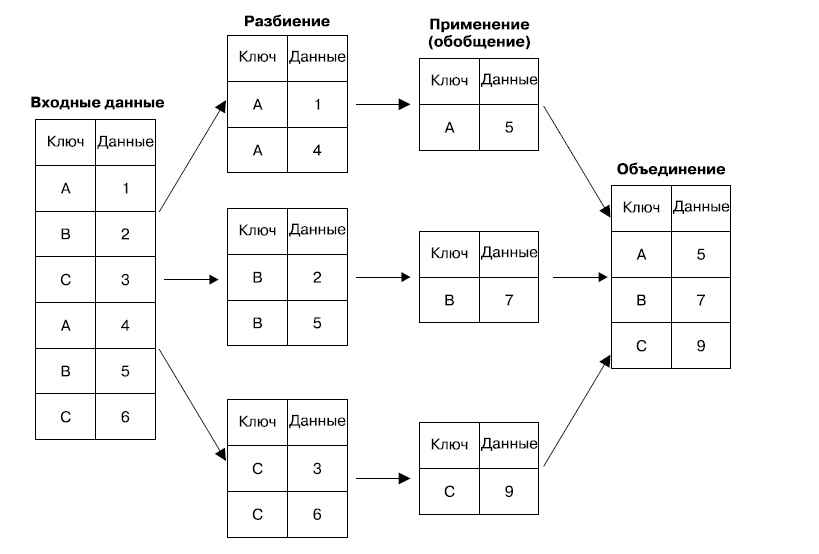

In [54]:
Image('pic1.png')

Рисунок  демонстрирует, что именно делает операция GroupBy.

- Шаг *разбиения* включает разделение на части и группировку объекта DataFrame на основе значений заданного ключа.
- Шаг *применения* включает вычисление какой-либо функции, обычно агрегирующей, преобразование или фильтрацию в пределах отдельных групп.
- На шаге *объединения* выполняется слияние результатов этих операций в выходной массив.

Хотя мы, конечно, могли бы сделать это вручную с помощью какого-либо сочетания описанных выше команд маскирования, агрегирования и слияния, важно понимать, что не обязательно создавать объекты для промежуточных разбиений. Операция `GroupBy` может проделать все это за один проход по данным, вычисляя сумму, среднее значение, количество, минимум и другие сводные показатели для каждой группы. Мощь операции `GroupBy` состоит в абстрагировании этих шагов: пользователю не нужно заботиться о том, как фактически выполняются вычисления, а можно вместо этого думать об операции в целом.

В качестве примера рассмотрим использование библиотеки Pandas для выполнения показанных на рисунке вычислений. Начнем с создания входного объекта `DataFrame`:

In [55]:
df = pd.DataFrame({'key': ['A', 'B', 'C', 'A', 'B', 'C'],
                    'data': range(6)}, columns=['key', 'data'])
df

,key,data
0,A,0
1,B,1
2,C,2
3,A,3
4,B,4
5,C,5


Простейшую операцию «разбить, применить, объединить» можно реализовать с помощью метода `groupby()` объекта `DataFrame`, передав в него имя желаемого ключевого столбца:

In [56]:
df.groupby('key')

Обратите внимание, что возвращаемое — не набор объектов `DataFrame`, а объект `DataFrameGroupBy`. Этот объект особенный, его можно рассматривать как специальное представление объекта `DataFrame`, готовое к группировке, но не выполняющее никаких фактических вычислений до этапа применения агрегирования. Подобный метод «отложенного вычисления» означает возможность очень эффективной реализации распространенных агрегирующих функций, причем практически прозрачным для пользователя образом.

Для получения результата можно вызвать один из агрегирующих методов этого объекта `DataFrameGroupBy`, что приведет к выполнению соответствующих шагов применения/объединения:

In [58]:
df.groupby('key').sum()

,data
key,
A,3
B,5
C,7


Метод `sum()` — лишь один из возможных вариантов в этой команде. Здесь можно использовать практически любую распространенную агрегирующую функцию библиотек `Pandas` или `NumPy`, равно как и практически любую корректную операцию объекта `DataFrame`.

#### Объект GroupBy

Объект `GroupBy` — очень гибкая абстракция. Во многом с ним можно обращаться как с коллекцией объектов `DataFrame`, и вся сложность будет скрыта от пользователя. Рассмотрим примеры на основе набора данных «Планеты».

Вероятно, самые важные из доступных благодаря объекту `GroupBy` операций — *агрегирование*, *фильтрация*, *преобразование* и *применение*. Мы обсудим каждую из них более подробно, но сначала познакомимся с другой функциональностью, которую можно использовать вместе с базовой операцией `GroupBy`.

**Индексация по столбцам**. Объект `GroupBy` поддерживает индексацию по столбцам аналогично объекту `DataFrame`, с возвратом модифицированного объекта `GroupBy`. Например:

In [59]:
planets.groupby('method')

In [60]:
planets.groupby('method')['orbital_period']

Здесь мы выбрали конкретную группу `Series` из исходной группы `DataFrame`, сославшись на соответствующее имя столбца. Как и в случае с объектом `GroupBy`, никаких вычислений не происходит до вызова для этого объекта какого-нибудь агрегирующего метода:

In [61]:
planets.groupby('method')['orbital_period'].median()

method
Astrometry                         631.180000
Eclipse Timing Variations         4343.500000
Imaging                          27500.000000
Microlensing                      3300.000000
Orbital Brightness Modulation        0.342887
Pulsar Timing                       66.541900
Pulsation Timing Variations       1170.000000
Radial Velocity                    360.200000
Transit                              5.714932
Transit Timing Variations           57.011000
Name: orbital_period, dtype: float64

Результат дает нам общее представление о масштабе чувствительности каждого из методов к периодам обращения (в днях).

**Цикл по группам**. Объект `GroupBy` поддерживает непосредственное выполнение циклов по группам с возвратом каждой группы в виде объекта `Series` или `DataFrame`:

In [62]:
for (method, group) in planets.groupby('method'):
    print('{0:30s} shape={1}'.format(method, group.shape))

Astrometry                     shape=(2, 6)
Eclipse Timing Variations      shape=(9, 6)
Imaging                        shape=(38, 6)
Microlensing                   shape=(23, 6)
Orbital Brightness Modulation  shape=(3, 6)
Pulsar Timing                  shape=(5, 6)
Pulsation Timing Variations    shape=(1, 6)
Radial Velocity                shape=(553, 6)
Transit                        shape=(397, 6)
Transit Timing Variations      shape=(4, 6)


Это может пригодиться для выполнения некоторых вещей вручную, хотя обычно быстрее воспользоваться встроенной функциональностью `apply`.

**Методы диспетчеризации**. Благодаря определенной магии классов языка `Python` все методы, не реализованные явным образом объектом `GroupBy`, будут передаваться далее и выполняться для групп, вне зависимости от того, являются ли они объектами `Series` или `DataFrame`. Например, можно использовать метод `describe()` объекта `DataFrame` для вычисления набора сводных показателей, описывающих каждую группу в данных:

In [63]:
planets.groupby('method')['year'].describe().unstack()

       method                       
count  Astrometry                          2.000000
       Eclipse Timing Variations           9.000000
       Imaging                            38.000000
       Microlensing                       23.000000
       Orbital Brightness Modulation       3.000000
       Pulsar Timing                       5.000000
       Pulsation Timing Variations         1.000000
       Radial Velocity                   553.000000
       Transit                           397.000000
       Transit Timing Variations           4.000000
mean   Astrometry                       2011.500000
       Eclipse Timing Variations        2010.000000
       Imaging                          2009.131579
       Microlensing                     2009.782609
       Orbital Brightness Modulation    2011.666667
       Pulsar Timing                    1998.400000
       Pulsation Timing Variations      2007.000000
       Radial Velocity                  2007.518987
       Transit             

Эта таблица позволяет получить лучшее представление о наших данных. Например, большинство планет было открыто методом измерения лучевой скорости (radial velocity method) и транзитным методом (transit method), хотя последний стал распространенным благодаря новым более точным телескопам только в последнее десятилетие. Похоже, что новейшими методами являются метод вариации времени транзитов (transit timing variation method) и метод модуляции орбитальной яркости (orbital brightness modulation method), которые до 2011 года не использовались для открытия новых планет.

Это всего лишь один пример полезности методов диспетчеризации. Обратите внимание, что они применяются к каждой отдельной группе, после чего результаты объединяются в объект `GroupBy` и возвращаются. Можно использовать для соответствующего объекта `GroupBy` любой допустимый метод объектов `Series/DataFrame`, что позволяет выполнять многие весьма гибкие и мощные операции!

### Агрегирование, фильтрация, преобразование, применение

Предыдущее обсуждение касалось агрегирования применительно к операции объединения, но доступны и другие возможности. В частности, у объектов `GroupBy` имеются методы `aggregate()`, `filter()`, `transform()` и `apply()`, эффективно выполняющие множество полезных операций до объединения сгруппированных данных.

В следующих подразделах мы будем использовать объект `DataFrame`:

In [2]:
rng = np.random.RandomState(0)
df = pd.DataFrame({'key': ['A', 'B', 'C', 'A', 'B', 'C'],
                    'data1': range(6),
                    'data2': rng.randint(0, 10, 6)},
                    columns = ['key', 'data1', 'data2'])

df

,key,data1,data2
0,A,0,5
1,B,1,0
2,C,2,3
3,A,3,3
4,B,4,7
5,C,5,9


**Агрегирование**. Мы уже знакомы со сводными показателями объекта `GroupBy`, вычисляемыми с помощью методов `sum()`, `median()` и т. п., но метод `aggregate()` обеспечивает еще большую гибкость. Он может принимать на входе строку, функцию или список и вычислять все сводные показатели сразу. Вот пример, включающий все вышеупомянутое:

In [3]:
df.groupby('key').aggregate(['min', np.median, max])

data1            data2           
      min median max   min median max
key                                  
A       0    1.5   3     3    4.0   5
B       1    2.5   4     0    3.5   7
C       2    3.5   5     3    6.0   9

Еще один удобный паттерн — передача в него словаря, связывающего имена столбцов с операциями, которые должны быть применены к этим столбцам:

In [4]:
df.groupby('key').aggregate({'data1': 'min',
                             'data2': 'max'})

,data1,data2
key,,
A,0,5
B,1,7
C,2,9


**Фильтрация**. Операция фильтрации дает возможность опускать данные в зависимости от свойств группы. Например, нам может понадобиться оставить в результате все группы, в которых стандартное отклонение превышает какое-либо критическое значение:

In [5]:
def filter_func(x):
    return x['data2'].std() > 4

print(df)
print(df.groupby('key').std())
print(df.groupby('key').filter(filter_func))

  key  data1  data2
0   A      0      5
1   B      1      0
2   C      2      3
3   A      3      3
4   B      4      7
5   C      5      9
       data1     data2
key                   
A    2.12132  1.414214
B    2.12132  4.949747
C    2.12132  4.242641
  key  data1  data2
1   B      1      0
2   C      2      3
4   B      4      7
5   C      5      9


Функция `filter()` возвращает булево значение, определяющее, прошла ли группа фильтрацию. В данном случае, поскольку стандартное отклонение группы A превышает 4, она удаляется из итогового результата.

**Преобразование.** В то время как агрегирующая функция должна возвращать сокращенную версию данных, преобразование может вернуть версию полного набора данных, преобразованную ради дальнейшей их перекомпоновки. При подобном преобразовании форма выходных данных совпадает с формой входных. Распространенный пример — центрирование данных путем вычитания среднего значения по группам:

In [3]:
df.groupby('key').transform(lambda x: x - x.mean())

,data1,data2
0,-1.5,1.0
1,-1.5,-3.5
2,-1.5,-3.0
3,1.5,-1.0
4,1.5,3.5
5,1.5,3.0


**Метод apply().** Метод `apply()` позволяет применять произвольную функцию к результатам группировки. В качестве параметра эта функция должна получать объект `DataFrame`, а возвращать или объект библиотеки `Pandas` (например, `DataFrame`, `Series`), или скалярное значение, в зависимости от возвращаемого значения будет вызвана соответствующая операция объединения.

Например, функция `apply()`, нормирующая первый столбец на сумму значений второго:

In [4]:
def norm_by_data2(x):
    # x – объект DataFrame сгруппированных значений
    x['data1'] /= x['data2'].sum()
    return x

print(df); print(df.groupby('key').apply(norm_by_data2))

  key  data1  data2
0   A      0      5
1   B      1      0
2   C      2      3
3   A      3      3
4   B      4      7
5   C      5      9
  key     data1  data2
0   A  0.000000      5
1   B  0.142857      0
2   C  0.166667      3
3   A  0.375000      3
4   B  0.571429      7
5   C  0.416667      9


Функция `apply()` в `GroupBy` достаточно гибка. Единственное требование, чтобы она принимала на входе объект `DataFrame` и возвращала объект библиотеки `Pandas` или скалярное значение; что вы делаете внутри, остается на ваше усмотрение!

### Задание ключа разбиения

В представленных ранее простых примерах мы разбивали объект `DataFrame` по одному столбцу. Это лишь один из многих вариантов задания принципа формирования групп, и мы сейчас рассмотрим некоторые другие возможности.

**Список, массив, объект Series и индекс как ключи группировки.** Ключ может быть любым рядом или списком такой же длины, как и у объекта `DataFrame`. Например:

In [5]:
L = [0, 1, 0, 1, 2, 0]

print(df)
print(df.groupby(L).sum())

  key  data1  data2
0   A      0      5
1   B      1      0
2   C      2      3
3   A      3      3
4   B      4      7
5   C      5      9
   data1  data2
0      7     17
1      4      3
2      4      7


Разумеется, это значит, что есть еще один, несколько более длинный способ выполнить вышеприведенную операцию `df.groupby('key')`:

In [6]:
print(df)
print(df.groupby('key').sum())

  key  data1  data2
0   A      0      5
1   B      1      0
2   C      2      3
3   A      3      3
4   B      4      7
5   C      5      9
     data1  data2
key              
A        3      8
B        5      7
C        7     12


**Словарь или объект Series**, связывающий индекс и группу. Еще один метод: указать словарь, задающий соответствие значений индекса и ключей группировки:

In [7]:
df2 = df.set_index('key')
mapping = {'A': 'vowel', 'B': 'consonant', 'C': 'consonant'}
print(df2)
print(df2.groupby(mapping).sum())

     data1  data2
key              
A        0      5
B        1      0
C        2      3
A        3      3
B        4      7
C        5      9
           data1  data2
consonant     12     19
vowel          3      8


**Любая функция языка Python.** Аналогично заданию соответствия можно передать функции `groupby` любую функцию, принимающую на входе значение индекса и возвращающую группу:

In [8]:
print(df2)
print(df2.groupby(str.lower).mean())

     data1  data2
key              
A        0      5
B        1      0
C        2      3
A        3      3
B        4      7
C        5      9
   data1  data2
a    1.5    4.0
b    2.5    3.5
c    3.5    6.0


**Список допустимых ключей.** Можно комбинировать любые из предыдущих вариантов ключей для группировки по мультииндексу:

In [9]:
df2.groupby([str.lower, mapping]).mean()

,,data1,data2
a,vowel,1.5,4.0
b,consonant,2.5,3.5
c,consonant,3.5,6.0


### Пример группировки

В качестве примера соберем все это вместе в нескольких строках кода на языке Python и подсчитаем количество открытых планет по методу открытия и десятилетию:

In [3]:
decade = 10 * (planets['year'] // 10)
decade = decade.astype('str') + 's'
decade.name = 'decade'
planets.groupby(['method', decade])['number'].sum().unstack().fillna(0)

decade,1980s,1990s,2000s,2010s
method,,,,
Astrometry,0.0,0.0,0.0,2.0
Eclipse Timing Variations,0.0,0.0,5.0,10.0
Imaging,0.0,0.0,29.0,21.0
Microlensing,0.0,0.0,12.0,15.0
Orbital Brightness Modulation,0.0,0.0,0.0,5.0
Pulsar Timing,0.0,9.0,1.0,1.0
Pulsation Timing Variations,0.0,0.0,1.0,0.0
Radial Velocity,1.0,52.0,475.0,424.0
Transit,0.0,0.0,64.0,712.0


Это демонстрирует возможности комбинирования нескольких из вышеописанных операций применительно к реальным наборам данных. Мы мгновенно получили представление о том, когда и как открывались экзопланеты в последние несколько десятилетий!

**НЕБОЛЬШОЕ УПРАЖНЕНИЕ** Теперь же я предложил бы углубиться в эти несколько строк кода и выполнить их пошагово, чтобы убедиться, что вы действительно понимаете, какой вклад в результат они вносят. Это в чем-то непростой пример, но благодаря хорошему пониманию элементов кода у вас появятся средства для исследования ваших собственных данных.

### Сводные таблицы

Мы уже видели возможности по исследованию отношений в наборе данных, предоставляемые абстракцией `GroupBy`. *Сводная таблица* (pivot table) — схожая операция, часто встречающаяся в электронных таблицах и других программах, работающих с табличными данными. Сводная таблица получает на входе простые данные в виде столбцов и группирует записи в двумерную таблицу, обеспечивающую многомерное представление данных. Различие между сводными таблицами и операцией `GroupBy` иногда неочевидно. Лично мне помогает представлять сводные таблицы как многомерную версию агрегирующей функции `GroupBy`. То есть вы выполняете операцию «разбить, применить, объединить», но как разбиение, так и объединение происходят не на одномерном индексе, а на двумерной координатной сетке.

#### Данные для примеров работы со сводными таблицами

Для примеров из этого раздела мы воспользуемся базой данных пассажиров парохода «Титаник», доступной через библиотеку `Seaborn`.

In [4]:
titanic = sns.load_dataset('titanic')

In [5]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Этот набор данных содержит информацию о каждом пассажире злополучного рейса, включая пол, возраст, класс, стоимость билета и многое другое.

### Сводные таблицы «вручную»

Чтобы узнать о данных больше, можно начать с группировки пассажиров по полу, информации о том, выжил ли пассажир, или какой-то их комбинации. Если вы читали предыдущий раздел, то можете воспользоваться операцией `GroupBy`. Например, посмотрим на коэффициент выживаемости в зависимости от пола:

In [6]:
titanic.groupby('sex')[['survived']].mean()

,survived
sex,
female,0.742038
male,0.188908


Это сразу же дает нам некоторое представление о наборе данных: в целом, три четверти находившихся на борту женщин выжило, в то время как из мужчин выжил только каждый пятый!

Однако хотелось бы заглянуть немного глубже и увидеть распределение выживших по полу и классу. Говоря языком `GroupBy`, можно было бы идти следующим путем: сгруппировать по классу и полу, выбрать выживших, применить агрегирующую функцию среднего значения, объединить получившиеся группы, после чего выполнить операцию `unstack` иерархического индекса, чтобы обнажить скрытую многомерность. В виде кода:

In [7]:
titanic.groupby(['sex', 'class'])['survived'].aggregate('mean').unstack()

class,First,Second,Third
sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


Это дает нам лучшее представление о том, как пол и класс влияли на выживаемость, но код начинает выглядеть несколько запутанным. Хотя каждый шаг этого конвейера представляется вполне осмысленным в свете ранее рассмотренных инструментов, такая длинная строка кода не особо удобна для чтения или использования. Двумерный `GroupBy` встречается настолько часто, что в состав библиотеки `Pandas` был включен удобный метод, `pivot_table`, позволяющий описывать более кратко данную разновидность многомерного агрегирования.

#### Синтаксис сводных таблиц

Вот эквивалентный вышеприведенной операции код, использующий метод `pivot_table` объекта `DataFrame`:

In [8]:
titanic.pivot_table('survived', index='sex', columns='class')

class,First,Second,Third
sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


Такая запись несравненно удобнее для чтения, чем подход с `GroupBy`, при том же результате. Как и можно было ожидать от трансатлантического круиза начала XX века, судьба благоприятствовала женщинам и первому классу. Женщины из первого класса выжили практически все (привет, Роуз!), из мужчин третьего класса выжила только десятая часть (извини, Джек!).

#### Многоуровневые сводные таблицы

Группировку в сводных таблицах, как и при операции `GroupBy`, можно задавать на нескольких уровнях и с множеством параметров. Например, интересно взглянуть на возраст в качестве третьего измерения. Разобьем данные на интервалы по возрасту с помощью функции `pd.cut`:

In [9]:
age = pd.cut(titanic['age'], [0, 18, 80])
titanic.pivot_table('survived', ['sex', age], 'class')

class               First    Second     Third
sex    age                                   
female (0, 18]   0.909091  1.000000  0.511628
       (18, 80]  0.972973  0.900000  0.423729
male   (0, 18]   0.800000  0.600000  0.215686
       (18, 80]  0.375000  0.071429  0.133663

Мы можем применить ту же стратегию при работе со столбцами. Добавим сюда информацию о стоимости билета, воспользовавшись функцией `pd.qcut` для автоматического вычисления квантилей:

In [10]:
fare = pd.qcut(titanic['fare'], 2)
titanic.pivot_table('survived', ['sex', age], [fare, 'class'])

fare            (-0.001, 14.454]                     (14.454, 512.329]  \
class                      First    Second     Third             First   
sex    age                                                               
female (0, 18]               NaN  1.000000  0.714286          0.909091   
       (18, 80]              NaN  0.880000  0.444444          0.972973   
male   (0, 18]               NaN  0.000000  0.260870          0.800000   
       (18, 80]              0.0  0.098039  0.125000          0.391304   

fare                                 
class              Second     Third  
sex    age                           
female (0, 18]   1.000000  0.318182  
       (18, 80]  0.914286  0.391304  
male   (0, 18]   0.818182  0.178571  
       (18, 80]  0.030303  0.192308

Результат представляет собой четырехмерную сводную таблицу с иерархическими индексами, выведенную в демонстрирующей отношения между значениями сетке.

#### Дополнительные параметры сводных таблиц

Полная сигнатура вызова метода `pivot_table` объектов `DataFrame` выглядит следующим образом:

In [14]:
titanic.pivot_table?

Мы уже видели примеры первых трех аргументов, в данном подразделе рассмотрим остальные. Два из параметров, `fill_value` и `dropna`, относятся к пропущенным значениям и интуитивно понятны, примеры их использования мы приводить не будем.

Ключевое слово `aggfunc` управляет тем, какой тип агрегирования применяется, по умолчанию это среднее значение. Как и в `GroupBy`, спецификация агрегирующей функции может быть строкой с одним из нескольких обычных вариантов ('sum', 'mean', 'count', 'min', 'max' и т. д.) или функцией, реализующей агрегирование (np.sum(), min(), sum() и т. п.). Кроме того, агрегирование может быть задано в виде словаря, связывающего столбец с любым из вышеперечисленных вариантов:

In [13]:
titanic.pivot_table(index='sex', columns='class',
                    aggfunc={'survived':sum, 'fare':'mean'})

fare                       survived             
class        First     Second      Third    First Second Third
sex                                                           
female  106.125798  21.970121  16.118810       91     70    72
male     67.226127  19.741782  12.661633       45     17    47

Обратите внимание, что мы опустили ключевое слово `values`, при задании `aggfunc` происходит автоматическое определение.

Иногда бывает полезно вычислять итоги по каждой группе. Это можно сделать с помощью ключевого слова `margins`:

In [15]:
titanic.pivot_table('survived', index='sex', columns='class', margins=True)

class,First,Second,Third,All
sex,,,,
female,0.968085,0.921053,0.500000,0.742038
male,0.368852,0.157407,0.135447,0.188908
All,0.629630,0.472826,0.242363,0.383838


Такие итоги автоматически дают нам информацию о выживаемости вне зависимости от класса, коэффициенте выживаемости по классу вне зависимости от пола и общем коэффициенте выживаемости 38 %. Метки для этих итогов можно задать с помощью ключевого слова `margins_name`, по умолчанию имеющего значение "All".

### Пример: данные о рождаемости

В качестве примера взглянем на находящиеся в открытом доступе данные о рождаемости в США, предоставляемые центрами по контролю заболеваний (Centers for Disease Control, CDC). Данные можно найти по адресу https://raw.githubusercontent.com/jakevdp/data-CDCbirths/master/births.csv

In [2]:
# Инструкция системного командного процессора для скачивания данных:
!curl -O https://raw.githubusercontent.com/jakevdp/data-CDCbirths/master/births.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
curl: (35) schannel: next InitializeSecurityContext failed: Unknown error (0x80092012) - Функция отзыва не смогла произвести проверку отзыва для сертификата.


In [3]:
births = pd.read_csv('births.csv')

Посмотрев на эти данные, мы обнаружим их относительную простоту — они содержат количество новорожденных, сгруппированных по дате и полу:

In [4]:
births.head()

,year,month,day,gender,births
0,1969,1,1.0,F,4046
1,1969,1,1.0,M,4440
2,1969,1,2.0,F,4454
3,1969,1,2.0,M,4548
4,1969,1,3.0,F,4548


Мы начнем понимать эти данные немного лучше, воспользовавшись сводной таблицей. Добавим в них столбец для десятилетия и взглянем на рождения девочек и мальчиков как функцию от десятилетия:

In [13]:
births['decade'] = 10 * (births['year'] // 10)
births.pivot_table('births', index='decade', columns='gender', aggfunc='sum')

gender,F,M
decade,,
1960,1752836,1845742
1970,16260348,17118785
1980,16336507,17171290


Сразу же видим, что в каждом десятилетии мальчиков рождается больше, чем девочек. Воспользуемся встроенными средствами построения графиков библиотеки `Pandas` для визуализации общего количества новорожденных в зависимости от года:

In [20]:
%matplotlib inline
import matplotlib.pyplot as plt
sns.set() # Используем стили библиотеки Seaborn

Text(0, 0.5, 'Общее количество новорожденных в течение года')

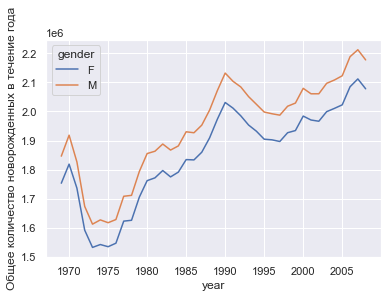

In [21]:
births.pivot_table('births', index='year', columns='gender', aggfunc='sum').plot()
plt.ylabel('Общее количество новорожденных в течение года')

Благодаря сводной таблице и методу `plot()` мы можем сразу же увидеть ежегодный тренд новорожденных по полу. В последние 50 с лишним лет мальчиков рождалось больше, чем девочек, примерно на 5 %.

**Дальнейшее исследование данных.** Хотя это, возможно, и не имеет отношения к сводным таблицам, есть еще несколько интересных вещей, которые можно извлечь из этого набора данных с помощью уже рассмотренных инструментов библиотеки `Pandas`. Нам придется начать с небольшой очистки данных, удалив аномальные значения, возникшие из-за неправильно набранных дат (например, 31 июня) или отсутствующих значений (например, 99 июня). Простой способ убрать сразу их все — отсечь аномальные значения. Мы сделаем это с помощью надежного алгоритма *сигма-отсечения* (sigma-clipping):

In [5]:
quartiles = np.percentile(births['births'], [25, 50, 75])
mu = quartiles[1]
sig = 0.74 * (quartiles[2] - quartiles[0])

Последняя строка представляет собой грубую оценку среднего значения выборки, в котором 0.74 — межквартильный размах Гауссового распределения. Теперь можно воспользоваться методом `query()` (обсуждаемым далее в разделе «Увеличение производительности библиотеки Pandas: eval() и query()») для фильтрации строк, в которых количество новорожденных выходит за пределы этих значений:

In [6]:
births = births.query('(births > @mu - 5 * @sig) & (births < @mu + 5 * @sig)')

Далее мы устанавливаем целочисленный тип столбца для day. Ранее он был строчным, поскольку некоторые столбцы в наборе данных содержат значение 'null':

In [7]:
# делаем тип столбца 'day' целочисленным;
# изначально он был строчным из-за пустых значений

births['day'] = births['day'].astype(int)

Наконец, мы можем создать индекс для даты, объединив день, месяц и год. Это даст нам возможность быстро вычислять день недели для каждой строки:

In [9]:
# создаем индекс для даты из года, месяца и дня
births.index = pd.to_datetime(10000 * births.year + 
                              100 * births.month + 
                              births.day, format='%Y%m%d')
births['dayofweek'] = births.index.dayofweek # День недели

С помощью этого можно построить график дней рождения в зависимости от дня недели за несколько десятилетий:

Text(0, 0.5, 'Среднее количество новорожденных в день')

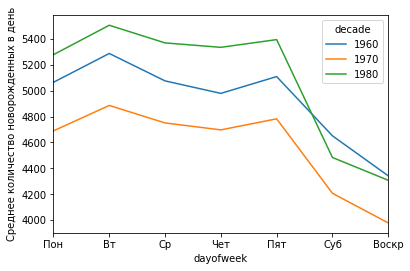

In [14]:
import matplotlib.pyplot as plt

births.pivot_table('births', index='dayofweek',
                   columns='decade', aggfunc='mean').plot()
plt.gca().set_xticklabels(['Пон', 'Вт', 'Ср', 'Чет', 'Пят','Суб','Воскр'])
plt.ylabel('Среднее количество новорожденных в день')

Становится очевидно, что в выходные происходит меньше рождений, чем в будние дни! Обратите внимание, что 1990-е и 2000-е годы отсутствуют на графике, поскольку начиная с 1989 года данные CDC содержат только месяц рождения.

Еще одно интересное представление этих данных можно получить, построив график рождений в зависимости от дня года. Сначала сгруппируем данные отдельно по месяцу и дню:

In [15]:
births_by_dayte = births.pivot_table('births', 
                                     [births.index.month, births.index.day])

In [16]:
births_by_dayte.head()

births
1 1  4009.225
  2  4247.400
  3  4500.900
  4  4571.350
  5  4603.625

Результат представляет собой мультииндекс по месяцам и дням. Чтобы упростить построение графика, преобразуем эти месяцы и дни в даты путем связывания их с фиктивным годом (обязательно выберите високосный год, чтобы обработать 29 февраля корректным образом!)

In [17]:
births_by_dayte.index = [pd.datetime(2012, month, day) for (month, day) in births_by_dayte.index]

In [18]:
births_by_dayte.head()

,births
2012-01-01,4009.225
2012-01-02,4247.400
2012-01-03,4500.900
2012-01-04,4571.350
2012-01-05,4603.625


Если смотреть только на месяц и день, то мы получаем временной ряд, отражающий среднее количество новорожденных в зависимости от дня года. Исходя из этого, мы можем построить с помощью метода `plot` график данных. В нем мы обнаруживаем некоторые любопытные тренды:

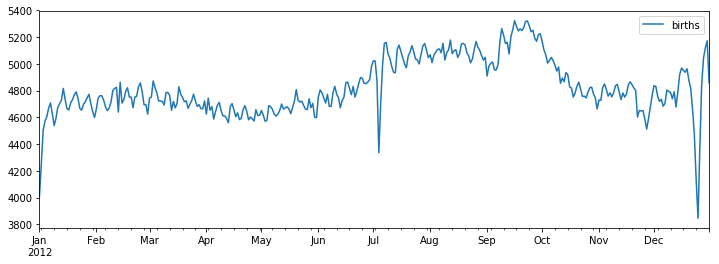

In [19]:
# Строим график результатов
fig, ax = plt.subplots(figsize=(12, 4))
births_by_dayte.plot(ax=ax);

### Таблицы методов работы со строками библиотеки Pandas

Если вы хорошо разбираетесь в манипуляции строковыми данными в языке Python, львиная доля синтаксиса работы со строками библиотеки Pandas будет вам интуитивно понятна настолько, что достаточно, наверное, просто привести таблицу имеющихся методов. С этого и начнем, прежде чем углубимся в некоторые нюансы. Примеры в этом разделе используют следующий ряд имен:

In [20]:
monte = pd.Series(['Graham Chapman', 'John Cleese', 'Terry Gilliam', 
                   'Eric Idle', 'Terry Jones', 'Michael Palin'])

### Методы, аналогичные строковым методам языка Python

Практически для всех встроенных строковых методов `Python` есть соответствующий векторизованный строковый метод библиотеки `Pandas`. Вот список методов атрибута `str` библиотеки `Pandas`, дублирующий строковые методы языка `Python`:

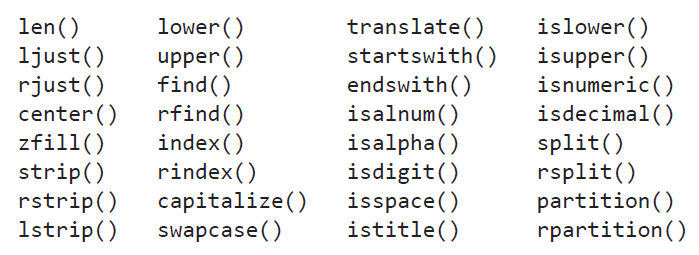

In [22]:
from IPython.display import Image
Image('pictures/pic2.png')

Обратите внимание, что возвращаемые значения у них отличаются. Некоторые, например `lower()`, возвращают `Series` строк:

In [23]:
monte.str.lower()

0    graham chapman
1       john cleese
2     terry gilliam
3         eric idle
4       terry jones
5     michael palin
dtype: object

Часть других возвращает числовые значения:

In [24]:
monte.str.len()

0    14
1    11
2    13
3     9
4    11
5    13
dtype: int64

Или булевы значения:

In [30]:
monte.str.startswith('T')

0    False
1    False
2     True
3    False
4     True
5    False
dtype: bool

Или списки и другие составные значения для каждого элемента:

In [31]:
monte.str.split()

0    [Graham, Chapman]
1       [John, Cleese]
2     [Terry, Gilliam]
3         [Eric, Idle]
4       [Terry, Jones]
5     [Michael, Palin]
dtype: object

### Методы, использующие регулярные выражения

Помимо этого, существует и несколько методов, принимающих на входе регулярные выражения для проверки содержимого каждого из строковых элементов и следующих некоторым соглашениям по API встроенного модуля re языка Python

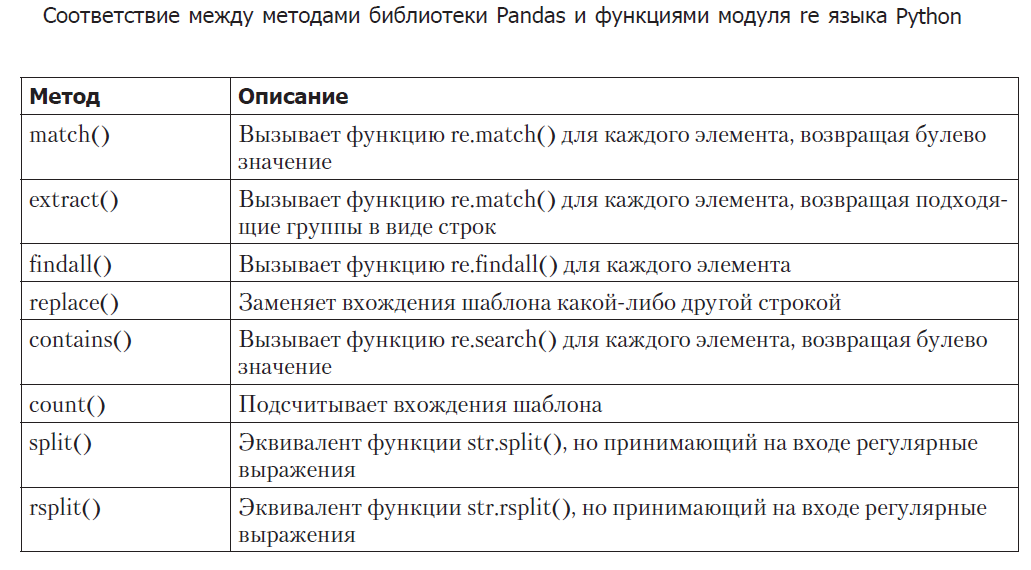

In [32]:
Image('pictures/pic3.png')

С помощью этих функций можно выполнять массу интересных операций. Например, можно извлечь имя из каждого элемента, выполнив поиск непрерывной группы символов в начале каждого из них:

In [33]:
monte.str.extract('([A-Za-z]+)')

,0
0,Graham
1,John
2,Terry
3,Eric
4,Terry
5,Michael


Или, например, найти все имена, начинающиеся и заканчивающиеся согласным звуком, воспользовавшись символами регулярных выражений «начало строки» (^) и «конец строки» ($):

In [34]:
monte.str.findall(r'^[^AEIOU].*[^aeiou]$')

0    [Graham Chapman]
1                  []
2     [Terry Gilliam]
3                  []
4       [Terry Jones]
5     [Michael Palin]
dtype: object

Такой сжатый синтаксис регулярных выражений для записей объектов `Series` и `DataFrame` открывает массу возможностей для анализа и очистки данных.

#### Прочие методы

Наконец, существуют и прочие методы, пригодные для разных удобных операций

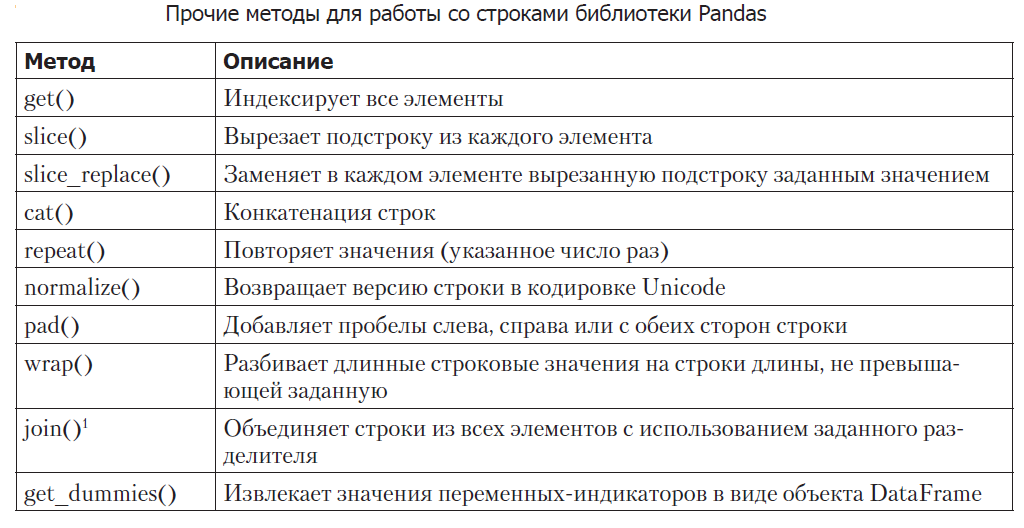

In [35]:
Image('pictures/pic4.png')

**Векторизованный доступ к элементам и вырезание подстрок.** Операции `get()` и `slice()`, в частности, предоставляют возможность векторизованного доступа к элементам из каждого массива. Например, можно вырезать первые три символа из каждого массива посредством выражения `str.slice(0, 3)`. Обратите внимание, что такая возможность доступна и с помощью обычного синтаксиса индексации языка Python, например, `df.str.slice(0, 3)` эквивалентно `df.str[0:3]`:

In [36]:
monte.str[0:3]

0    Gra
1    Joh
2    Ter
3    Eri
4    Ter
5    Mic
dtype: object

Индексация посредством `df.str.get(i)` и `df.str[i]` происходит аналогично.

Эти методы `get()` и `slice()` также дают возможность обращаться к элементам возвращаемых методом `split()` массивов. Например, для извлечения фамилии из каждой записи можно использовать вместе методы `split()` и `get()`:

In [37]:
monte.str.split().str.get(-1)

0    Chapman
1     Cleese
2    Gilliam
3       Idle
4      Jones
5      Palin
dtype: object

**Индикаторные переменные.** Еще один метод, требующий некоторых дополнительных пояснений, — `get_dummies()`. Удобно, когда в данных имеется столбец, содержащий кодированный индикатор. Например, у нас есть набор данных, содержащий информацию в виде кодов, таких как A="родился в США", B="родился в Великобритании", C="любит сыр", D="любит мясные консервы":

In [38]:
full_monte = pd.DataFrame({'name': monte,
                           'info': ['B|C|D', 'B|D', 'A|C', 'B|D', 'B|C',
                           'B|C|D']})

In [39]:
full_monte

,name,info
0,Graham Chapman,B|C|D
1,John Cleese,B|D
2,Terry Gilliam,A|C
3,Eric Idle,B|D
4,Terry Jones,B|C
5,Michael Palin,B|C|D


Метод `get_dummies()` дает возможность быстро разбить все индикаторные переменные, преобразовав их в объект DataFrame:

In [40]:
full_monte['info'].str.get_dummies('|')

,A,B,C,D
0,0,1,1,1
1,0,1,0,1
2,1,0,1,0
3,0,1,0,1
4,0,1,1,0
5,0,1,1,1


Используя эти операции как «строительные блоки», можно создать бесчисленное множество обрабатывающих строки процедур для очистки данных.

### Работа с временными рядами

Библиотека `Pandas` была разработана в расчете на построение финансовых моделей, так что, как вы могли и ожидать, она содержит весьма широкий набор инструментов для работы с датой, временем и индексированными по времени данными. Данные о дате и времени могут находиться в нескольких видах, которые мы сейчас обсудим.

- *Метки даты/времени* ссылаются на конкретные моменты времени (например, 4 июля 2015 года в 07:00 утра).
- *Временные интервалы* и *периоды* ссылаются на отрезки времени между конкретными начальной и конечной точками (например, 2015 год). Периоды обычно представляют собой особый случай интервалов, с непересекающимися интервалами одинаковой длительности (например, 24-часовые периоды времени, составляющие сутки).
- *Временная дельта* (она же продолжительность) относится к отрезку времени конкретной длительности (например, 22,56 с).

### Дата и время в языке Python

В мире языка Python существует немало представлений дат, времени, временных дельт и интервалов времени. Хотя для приложений науки о данных наиболее удобны инструменты работы с временными рядами библиотеки `Pandas`, не помешает посмотреть на другие используемые в Python пакеты.

#### Нативные даты и время языка Python: пакеты datetime и dateutil

Базовые объекты `Python` для работы с датами и временем располагаются во встроенном пакете `datetime`. Его, вместе со сторонним модулем `dateutil`, можно использовать для быстрого выполнения множества удобных операций над датами и временем. Например, можно вручную сформировать дату с помощью типа `datetime`:

In [7]:
from datetime import datetime
datetime(year=2016, month=10, day=12)

datetime.datetime(2016, 10, 12, 0, 0)

Или, воспользовавшись модулем `dateutil`, можно выполнять синтаксический разбор дат, находящихся во множестве строковых форматов:

In [2]:
from dateutil import parser
date = parser.parse('12th of October, 2016')

In [3]:
date

datetime.datetime(2016, 10, 12, 0, 0)

При наличии объекта `datetime` можно делать вывод дня недели:

In [4]:
date.strftime('%A')

'Wednesday'

В этой команде мы использовали для вывода даты один из стандартных кодов форматирования строк `("%A")`, о котором можно прочитать в разделе strftime (https://docs.python.org/3/library/datetime.html#strftime-and-strptime-behavior) документации по пакету datetime (https://docs.python.org/3/library/datetime.html) языка Python. Документацию по другим полезным утилитам для работы с датой и временем можно найти в онлайн-документации пакета `dateutil` (http://labix.org/python-dateutil). Не помешает также быть в курсе связанного с ними пакета `pytz` (http://pytz.sourceforge.net), содержащего инструменты для работы с частью данных временных рядов — часовыми поясами.

Сила пакетов `datetime` и `dateutil` заключается в их гибкости и удобном синтаксисе: эти объекты и их встроенные методы можно использовать для выполнения практически любой интересующей вас операции. Единственное, в чем они работают плохо, это работа с большими массивами дат и времени: подобно спискам числовых переменных языка Python, работающим неоптимально по сравнению с типизированными числовыми массивами в стиле библиотеки NumPy, списки объектов даты/времени Python работают с меньшей производительностью, чем типизированные массивы кодированных дат.

### Типизированные массивы значений времени: тип datetime64 библиотеки NumPy

Указанная слабая сторона формата даты/времени языка Python побудила команду разработчиков библиотеки `NumPy` добавить набор нативных типов данных временных рядов. Тип (dtype) datetime64 кодирует даты как 64-битные целые числа, так что представление массивов дат оказывается очень компактным. Для типа `datetime64` требуется очень точно заданный формат входных данных:

In [5]:
date = np.array('2016-05-23', dtype=np.datetime64)
date

array('2016-05-23', dtype='datetime64[D]')

Но как только дата отформатирована, можно быстро выполнять над ней различные векторизованные операции:

In [6]:
date + np.arange(12)

array(['2016-05-23', '2016-05-24', '2016-05-25', '2016-05-26',
       '2016-05-27', '2016-05-28', '2016-05-29', '2016-05-30',
       '2016-05-31', '2016-06-01', '2016-06-02', '2016-06-03'],
      dtype='datetime64[D]')

Поскольку `datetime64`-массивы библиотеки `NumPy` содержат данные одного типа, подобные операции выполняются намного быстрее, чем если работать непосредственно с объектами `datetime` языка Python, особенно если речь идет о больших массивах.

Важный нюанс относительно объектов `datetime64` и `timedelta64`: они основаны на *базовой единице времени* (fundamental time unit). Поскольку объект `datetime64` ограничен точностью 64 бита, кодируемый им диапазон времени составляет эту базовую единицу, умноженную на $2^{64}$. Другими словами, `datetime64` навязывает компромисс между разрешающей способностью по времени и максимальным промежутком времени.

Например, если нам требуется разрешающая способность 1 наносекунда, то у нас будет информация, достаточная для кодирования только интервала $2^{64}$ наносекунды, или чуть более 600 лет. Библиотека NumPy определяет требуемую единицу на основе входной информации; например, вот дата/время на основе единицы в один день:

In [7]:
np.datetime64('2019-06-19')

numpy.datetime64('2019-06-19')

Вот дата/время на основе единицы в одну минуту:

In [10]:
np.datetime64('2019-06-19 12:00')

numpy.datetime64('2019-06-19T12:00')

Обратите внимание, что часовой пояс автоматически задается в соответствии с местным временем выполняющего код компьютера. Можно обеспечить принудительное использование любой требуемой базовой единицы с помощью одного из множества кодов форматирования; например, вот дата/время на основе единицы в одну наносекунду:

In [11]:
np.datetime64('2019-06-19 12:59:59.50', 'ns')

numpy.datetime64('2019-06-19T12:59:59.500000000')

Удобное значение по умолчанию для типов данных, встречающихся в реальном мире, — `datetime64[ns]`, позволяющее кодировать достаточный диапазон современных дат с высокой точностью.

Наконец, отметим, что, хотя тип данных `datetime64` лишен некоторых недостатков встроенного типа данных `datetime` языка Python, ему недостает многих предоставляемых `datetime` и особенно `dateutil` удобных методов и функций. Больше информации можно найти в документации по типу `datetime64` библиотеки NumPy (http://docs.scipy.org/doc/numpy/reference/arrays.datetime.html).

### Даты и время в библиотеке Pandas: избранное из лучшего

Библиотека `Pandas` предоставляет, основываясь на всех только что обсуждавшихся инструментах, объект `Timestamp`, сочетающий удобство использования `datetime` и `dateutil` с эффективным хранением и векторизованным интерфейсом типа `numpy.datetime64`. Библиотека `Pandas` умеет создавать из нескольких таких объектов `Timestamp` объект класса `DatetimeIndex`, который можно использовать для индексации данных в объектах `Series` или `DataFrame`. Можно применить инструменты библиотеки `Pandas` для воспроизведения вышеприведенной наглядной демонстрации. Можно выполнить синтаксический разбор строки с датой в гибком формате и воспользоваться кодами форматирования, чтобы вывести день недели:

In [12]:
date = pd.to_datetime('23rd of May, 2019')
date

Timestamp('2019-05-23 00:00:00')

In [13]:
date.strftime('%A')

'Thursday'

Кроме этого, можно выполнять векторизованные операции в стиле библиотеки `NumPy` непосредственно над этим же объектом:

In [14]:
date + pd.to_timedelta(np.arange(12), 'D')

DatetimeIndex(['2019-05-23', '2019-05-24', '2019-05-25', '2019-05-26',
               '2019-05-27', '2019-05-28', '2019-05-29', '2019-05-30',
               '2019-05-31', '2019-06-01', '2019-06-02', '2019-06-03'],
              dtype='datetime64[ns]', freq=None)

### Временные ряды библиотеки Pandas: индексация по времени

Инструменты для работы с временными рядами библиотеки Pandas особенно удобны при необходимости *индексации данных по меткам даты/времени*. Например, создадим объект `Series` с индексированными по времени данными:

In [3]:
index = pd.DatetimeIndex(['2014-01-01', '2016-10-13', '2019-05-23',  '2019-06-19'])
data = pd.Series([0, 1, 2, 3], index=index)
data

2014-01-01    0
2016-10-13    1
2019-05-23    2
2019-06-19    3
dtype: int64

Теперь, когда эти данные находятся в объекте `Series`, можно использовать для них любые из обсуждавшихся в предыдущих разделах паттернов индексации `Series`, передавая значения, которые допускают приведение к типу даты:

In [4]:
data['2014-01-01':'2019-05-23']

2014-01-01    0
2016-10-13    1
2019-05-23    2
dtype: int64

Имеются также дополнительные специальные операции индексации, предназначенные только для дат. Например, можно указать год, чтобы получить срез всех данных за этот год:

In [5]:
data['2019']

2019-05-23    2
2019-06-19    3
dtype: int64

### Структуры данных для временных рядов библиотеки Pandas

В этом разделе мы рассмотрим основные структуры данных, предназначенные для работы с временными рядами.

- Для *меток даты/времени* библиотека Pandas предоставляет тип данных `Timestamp`. Этот тип является заменой для нативного типа данных `datetime` языка Python, он основан на более эффективном типе данных `numpy.datetime64`. Соответствующая индексная конструкция — `DatetimeIndex`.
- Для *периодов времени* библиотека `Pandas` предоставляет тип данных `Period`. Этот тип на основе типа данных `numpy.datetime64` кодирует интервал времени фиксированной периодичности. Соответствующая индексная конструкция — `PeriodIndex`.
- Для *временных дельт* (продолжительностей) библиотека `Pandas` предоставляет тип данных `Timedelta`. `Timedelta` — основанная на типе `numpy.timedelta64` более эффективная замена нативного типа данных `datetime.timedelta` языка Python. Соответствующая индексная конструкция — `TimedeltaIndex`.

Самые базовые из этих объектов даты/времени — объекты `Timestamp` и `DatetimeIndex`. Хотя к ним и можно обращаться непосредственно, чаще используют функцию `pd.to_datetime()`, умеющую выполнять синтаксический разбор широкого диапазона форматов. При передаче в функцию `pd.to_datetime()` отдельной даты она возвращает `Timestamp`, при передаче ряда дат по умолчанию возвращает `DatetimeIndex`:

In [11]:
dates = pd.to_datetime([datetime(2013, 10, 18), '19th of October, 2013',
                        '2013-Oct-20', '21-10-2013', '20131022'])
dates

DatetimeIndex(['2013-10-18', '2013-10-19', '2013-10-20', '2013-10-21',
               '2013-10-22'],
              dtype='datetime64[ns]', freq=None)

Любой объект `DatetimeIndex` можно с помощью функции `to_period()` преобразовать в объект `PeriodIndex`, указав код для периодичности интервала. В данном случае мы использовали код 'D', означающий, что периодичность интервала — один день:

In [12]:
dates.to_period('D')

PeriodIndex(['2013-10-18', '2013-10-19', '2013-10-20', '2013-10-21',
             '2013-10-22'],
            dtype='period[D]', freq='D')

Объект `TimedeltaIndex` создается, например, при вычитании одной даты из другой:

In [13]:
dates - dates[0]

TimedeltaIndex(['0 days', '1 days', '2 days', '3 days', '4 days'], dtype='timedelta64[ns]', freq=None)

**Регулярные последовательности:** функция `pd.date_range()`. Чтобы облегчить создание регулярных последовательностей, библиотека `Pandas` предоставляет несколько функций: `pd.date_range()` — для меток даты/времени, `pd.period_range()` — для периодов времени и `pd.timedelta_range()` — для временных дельт. Мы уже видели, что функции `range()` языка Python и `np.arange()` библиотеки NumPy преобразуют начальную точку, конечную точку и (необязательную) величину шага в последовательность. Аналогично функция `pd.date_range()` создает регулярную последовательность дат, принимая на входе начальную дату, конечную дату и необязательный код периодичности. По умолчанию период равен одному дню:

In [14]:
pd.date_range('2020-11-01', '2020-11-14')

DatetimeIndex(['2020-11-01', '2020-11-02', '2020-11-03', '2020-11-04',
               '2020-11-05', '2020-11-06', '2020-11-07', '2020-11-08',
               '2020-11-09', '2020-11-10', '2020-11-11', '2020-11-12',
               '2020-11-13', '2020-11-14'],
              dtype='datetime64[ns]', freq='D')

В качестве альтернативы можно также задать диапазон дат с помощью не начальной и конечной точек, а посредством начальной точки и количества периодов времени:

In [15]:
pd.date_range('2020-11-01', periods=7)

DatetimeIndex(['2020-11-01', '2020-11-02', '2020-11-03', '2020-11-04',
               '2020-11-05', '2020-11-06', '2020-11-07'],
              dtype='datetime64[ns]', freq='D')

Можно изменить интервал времени, поменяв аргумент `freq`, имеющий по умолчанию значение 'D'. Например, в следующем фрагменте мы создаем диапазон часовых меток даты/времени:

In [17]:
pd.date_range('2020-11-04', periods=8, freq='H')

DatetimeIndex(['2020-11-04 00:00:00', '2020-11-04 01:00:00',
               '2020-11-04 02:00:00', '2020-11-04 03:00:00',
               '2020-11-04 04:00:00', '2020-11-04 05:00:00',
               '2020-11-04 06:00:00', '2020-11-04 07:00:00'],
              dtype='datetime64[ns]', freq='H')

In [18]:
pd.date_range('2020-11-04 08:00:00', periods=8, freq='H')

DatetimeIndex(['2020-11-04 08:00:00', '2020-11-04 09:00:00',
               '2020-11-04 10:00:00', '2020-11-04 11:00:00',
               '2020-11-04 12:00:00', '2020-11-04 13:00:00',
               '2020-11-04 14:00:00', '2020-11-04 15:00:00'],
              dtype='datetime64[ns]', freq='H')

Для создания регулярных последовательностей значений периодов или временных дельт можно воспользоваться функциями `pd.period_range()` и `pd.timedelta_range()`, напоминающими функцию `date_range()`. Вот несколько периодов времени длительностью в месяц:

In [19]:
pd.period_range('2020-09', periods=8, freq='M')

PeriodIndex(['2020-09', '2020-10', '2020-11', '2020-12', '2021-01', '2021-02',
             '2021-03', '2021-04'],
            dtype='period[M]', freq='M')

In [20]:
pd.timedelta_range(0, periods=10, freq='H')

TimedeltaIndex(['00:00:00', '01:00:00', '02:00:00', '03:00:00', '04:00:00',
                '05:00:00', '06:00:00', '07:00:00', '08:00:00', '09:00:00'],
               dtype='timedelta64[ns]', freq='H')

Все эти операции требуют понимания кодов периодичности, приведенных в следующем разделе.

#### Периодичность и смещения дат

Периодичность или смещение даты — базовое понятие для инструментов библиотеки `Pandas`, необходимых для работы с временными рядами. Аналогично уже продемонстрированным кодам D (день) и H (час) можно использовать коды для задания любой требуемой периодичности. В таблице ниже описаны основные существующие коды.

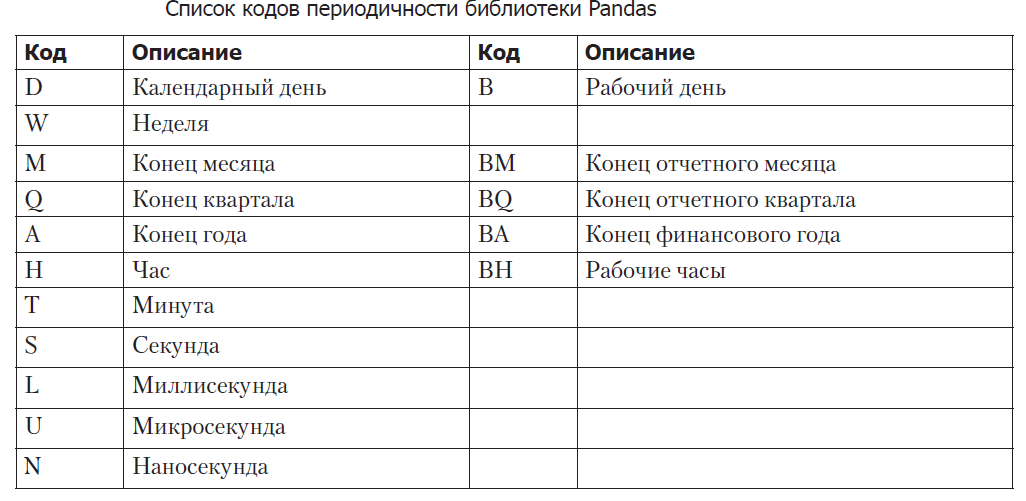

In [21]:
from IPython.display import Image
Image('pictures/pic5.png')

Периодичность в месяц, квартал и год определяется на конец соответствующего периода. Добавление к любому из кодов суффикса S приводит к определению начала периода

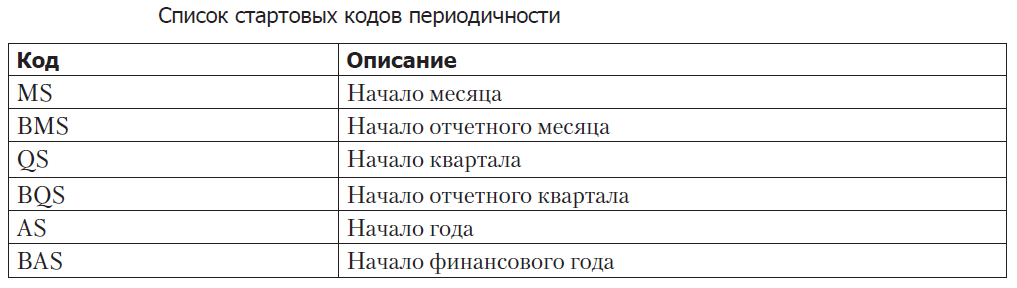

In [22]:
Image('pictures/pic6.png')

Кроме этого, можно изменить используемый для определения квартала или года месяц с помощью добавления в конец кода месяца, состоящего из трех букв:

- Q-JAN, BQ-FEB, QS-MAR, BQS-APR и т. д.
- A-JAN, BA-FEB, AS-MAR, BAS-APR и т. д.

Аналогичным образом можно изменить точку разбиения для недельной периодичности, добавив состоящий из трех букв код дня недели:

W-SUN, W-MON, W-TUE, W-WED и т. д.

Для указания иной периодичности можно сочетать коды с числами. Например, для периодичности 2 часа 30 минут можно скомбинировать коды для часа (H) и минуты (T):

In [6]:
pd.timedelta_range(0, periods=9, freq='2H30T')

TimedeltaIndex(['00:00:00', '02:30:00', '05:00:00', '07:30:00', '10:00:00',
                '12:30:00', '15:00:00', '17:30:00', '20:00:00'],
               dtype='timedelta64[ns]', freq='150T')

В данном разделе приведена лишь краткая сводка некоторых наиболее важных возможностей инструментов для работы с временными рядами библиотеки `Pandas`. Более развернутое обсуждение этой темы можно найти в разделе Time Series/Date («Временные ряды/даты») онлайн-документации библиотеки Pandas (http://pandas.pydata.org/pandas-docs/stable/timeseries.html).

### Пример: визуализация количества велосипедов в Сиэтле

В качестве более сложного примера работы с данными временных рядов рассмотрим подсчет количества велосипедов на Фримонтском мосту в Сиэтле. Эти данные поступают из автоматического счетчика велосипедов, установленного в конце 2012 года с индуктивными датчиками на восточной и западной боковых дорожках моста. Сведения о почасовом количестве велосипедов можно скачать по адресу http://data.seattle.gov/; вот прямая ссылка на набор данных: https://data.seatt-le.gov/Transportation/Fremont-Bridge-Hourly-Bicycle-Counts-by-Month-Octo/65db-xm6k.

После скачивания набора данных можно воспользоваться библиотекой `Pandas` для чтения CSV-файла в объект `DataFrame`. Можно указать, что в качестве индекса мы хотим видеть объекты `Date` и чтобы выполнялся автоматический синтаксический разбор этих дат:

In [8]:
data = pd.read_csv('Fremont_Bridge_Bicycle_Counter.csv', index_col='Date', parse_dates=True)
data.head()

,Fremont Bridge Total,Fremont Bridge East Sidewalk,Fremont Bridge West Sidewalk
Date,,,
2012-10-03 00:00:00,13.0,4.0,9.0
2012-10-03 01:00:00,10.0,4.0,6.0
2012-10-03 02:00:00,2.0,1.0,1.0
2012-10-03 03:00:00,5.0,2.0,3.0
2012-10-03 04:00:00,7.0,6.0,1.0


Теперь рассмотрим сводные статистические показатели для этих данных:

In [9]:
data.dropna().describe()

,Fremont Bridge Total,Fremont Bridge East Sidewalk,Fremont Bridge West Sidewalk
count,136313.000000,136313.000000,136313.000000
mean,112.975065,51.514060,61.461005
std,143.607191,66.214446,89.406687
min,0.000000,0.000000,0.000000
25%,14.000000,6.000000,7.000000
50%,61.000000,28.000000,30.000000
75%,148.000000,69.000000,75.000000
max,1097.000000,698.000000,850.000000


#### Визуализация данных

Мы можем почерпнуть полезную информацию из этого набора данных, визуализировав его. Начнем с построения графика исходных данных

In [10]:
%matplotlib inline
import seaborn; seaborn.set()

Text(0, 0.5, 'Количество велосипедов по часам')

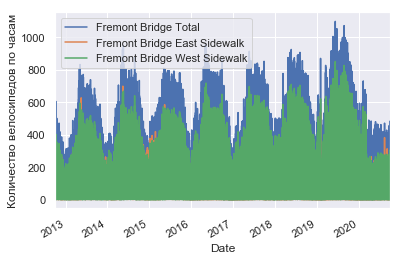

In [11]:
data.plot()
plt.ylabel('Количество велосипедов по часам')

Примерно 25 000 почасовых выборок — слишком плотная дискретизация, чтобы можно было понять хоть что-то. Можно почерпнуть больше информации, если выполнить передискретизацию этих данных на сетке с более крупным шагом. Выполним передискретизацию с шагом одна неделя:

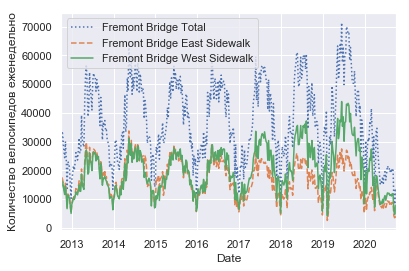

In [12]:
weekly = data.resample('W').sum()
weekly.plot(style=[':', '--', '-'])
plt.ylabel('Количество велосипедов еженедельно');

Еще один удобный способ агрегирования данных — вычисление скользящего среднего с помощью функции `pd.rolling`. Здесь мы вычисляем для наших данных скользящее среднее за 30 дней, центрируя при этом окно:

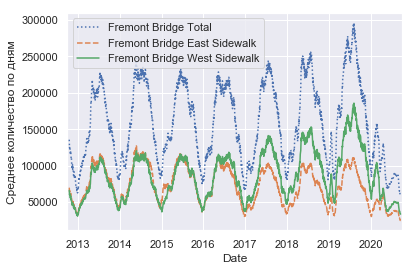

In [15]:
daily = data.resample('D').sum()
daily.rolling(30, center=True).sum().plot(style=[':', '--', '-'])
plt.ylabel('Среднее количество по дням');

Причина зубчатости получившего изображения — в резкой границе окна. Более гладкую версию скользящего среднего можно получить, воспользовавшись оконной функцией, например Гауссовым окном. Следующий код  задает как ширину окна (в нашем случае 50 дней), так и ширину Гауссовой функции внутри окна (в нашем случае 10 дней):

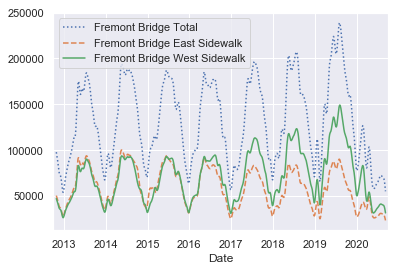

In [16]:
daily.rolling(50, center=True, win_type='gaussian').sum(std=10).plot(style=[':', '--', '-']);

#### Углубляемся в изучение данных

Хотя с помощью сглаженных представлений данных  можно получить общее представление о трендах данных, они скрывают от нас многие интересные нюансы их структуры. Например, нам может понадобиться увидеть усредненное движение велосипедного транспорта как функцию от времени суток. Это можно сделать с помощью функциональности `GroupBy`:

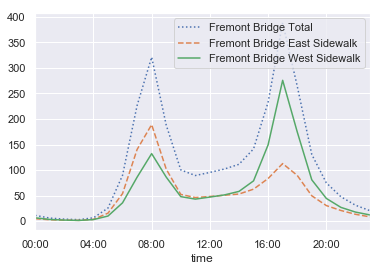

In [17]:
by_time = data.groupby(data.index.time).mean()
hourly_ticks = 4 * 60 * 60 * np.arange(6)
by_time.plot(xticks=hourly_ticks, style=[':', '--', '-']);

Почасовое движение транспорта представляет собой строго бимодальное распределение с максимумами в 08:00 утра и 05:00 вечера. Вероятно, это свидетельствует о существенном вкладе маятниковой миграции через мост. В пользу этого говорят и различия между значениями с западной боковой дорожки (обычно используемой при движении в деловой центр Сиэтла) с более выраженными утренними максимумами и значениями с восточной боковой дорожки (обычно используемой при движении из делового центра Сиэтла) с более выраженными вечерними максимумами.

Нас могут также интересовать изменения ситуации по дням недели. Это можно выяснить с помощью операции `groupby`:

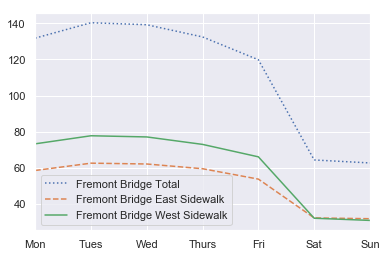

In [18]:
by_weekday = data.groupby(data.index.dayofweek).mean()
by_weekday.index = ['Mon', 'Tues', 'Wed', 'Thurs',
                    'Fri', 'Sat', 'Sun']
by_weekday.plot(style=[':', '--', '-']);

Этот график демонстрирует существенное различие между количеством велосипедов в будние и выходные дни: с понедельника по пятницу мост пересекает в среднем вдвое больше велосипедистов, чем в субботу и воскресенье.

С учетом этого выполним сложную операцию `groupby` и посмотрим на почасовой тренд в будни по сравнению с выходными. Начнем с группировки как по признаку выходного дня, так и по времени суток:

In [19]:
weekend = np.where(data.index.weekday < 5, 'Weekday', 'Weekend')
by_time = data.groupby([weekend, data.index.time]).mean()

C:\Users\sophi\Anaconda3\lib\site-packages\ipykernel_launcher.py:4: DeprecationWarning: 
.ix is deprecated. Please use
.loc for label based indexing or
.iloc for positional indexing

See the documentation here:
http://pandas.pydata.org/pandas-docs/stable/indexing.html#ix-indexer-is-deprecated
  after removing the cwd from sys.path.
C:\Users\sophi\Anaconda3\lib\site-packages\ipykernel_launcher.py:6: DeprecationWarning: 
.ix is deprecated. Please use
.loc for label based indexing or
.iloc for positional indexing

See the documentation here:
http://pandas.pydata.org/pandas-docs/stable/indexing.html#ix-indexer-is-deprecated
  


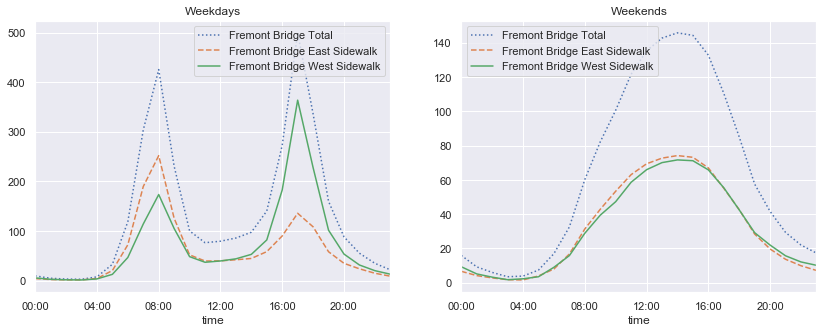

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
by_time.ix['Weekday'].plot(ax=ax[0], title='Weekdays',
                           xticks=hourly_ticks, style=[':', '--', '-'])
by_time.ix['Weekend'].plot(ax=ax[1], title='Weekends',
                           xticks=hourly_ticks, style=[':', '--', '-']);

Результат оказался очень интересным: мы видим бимодальный паттерн, связанный с поездками на работу в город на протяжении рабочей недели, и унимодальный паттерн, связанный с досугом/отдыхом во время выходных.

### Увеличение производительности библиотеки Pandas: eval() и query()

Основные возможности стека `PyData` основываются на умении библиотек `NumPy` и `Pandas` передавать простые операции на выполнение программам на языке C посредством интуитивно понятного синтаксиса: примерами могут послужить векторизованные/транслируемые операции в библиотеке NumPy, а также операции группировки в библиотеке Pandas. Хотя эти абстракции весьма производительны и эффективно работают для многих распространенных сценариев использования, они зачастую требуют создания временных вспомогательных объектов, что приводит к чрезмерным накладным расходам как процессорного времени, так и оперативной памяти.

Библиотека Pandas включает некоторые экспериментальные инструменты, позволяющие обращаться к работающим со скоростью написанных на языке C операциям без выделения существенных объемов памяти на промежуточные массивы. Эти утилиты — функции `eval()` и `query()`, основанные на пакете Numexpr (https://github.com/pydata/numexpr). Мы рассмотрим их использование и приведем некоторые эмпирические правила, позволяющие решить, имеет ли смысл их применять.

#### Основания для использования функций query() и eval(): составные выражения

Библиотеки `NumPy` и `Pandas` поддерживают выполнение быстрых векторизованных операций; например, при сложении элементов двух массивов:

In [32]:
rng = np.random.RandomState(42)
x = rng.rand(1000000)
y = rng.rand(1000000)
 
%timeit x + y

5.36 ms ± 229 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


Как уже обсуждалось в предыдущей лабораторной, такая операция выполняется гораздо быстрее, чем сложение с помощью цикла или спискового включения языка Python:

In [34]:
%timeit np.fromiter((xi + yi for xi, yi in zip(x, y)), dtype=x.dtype, count=len(x))

647 ms ± 21.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


Однако данная абстракция оказывается менее эффективной при вычислении составных выражений. Например, рассмотрим выражение:

In [35]:
mask = (x > 0.5) & (y < 0.5)

Поскольку библиотека NumPy вычисляет каждое подвыражение, оно эквивалентно следующему:

In [36]:
tmp1 = (x > 0.5)
tmp2 = (y < 0.5)
mask = tmp1 & tmp2

Другими словами, для каждого *промежуточного шага явным образом выделяется оперативная память*. Если массивы `x` и `y` очень велики, это может привести к значительным накладным расходам оперативной памяти и процессорного времени.

Библиотека `Numexpr` позволяет вычислять подобные составные выражения поэлементно, не требуя выделения памяти под промежуточные массивы целиком. В документации библиотеки `Numexpr` (https://github.com/pydata/numexpr) приведено больше подробностей, но пока достаточно будет сказать, что функции этой библиотеки принимают на входе *строку*, содержащую выражение в стиле библиотеки NumPy, которое требуется вычислить:

In [37]:
import numexpr

mask_numexpr = numexpr.evaluate('(x > 0.5) & (y < 0.5)')
np.allclose(mask, mask_numexpr)

True

Преимущество заключается в том, что библиотека Numexpr вычисляет выражение, не используя полноразмерных временных массивов, а потому оказывается намного более эффективной, чем NumPy, особенно в случае больших массивов. Инструменты `query()` и `eval()`, которые мы будем обсуждать, идеологически схожи и используют пакет Numexpr.

### Использование функции pandas.eval() для эффективных операций

Функция `eval()` библиотеки Pandas применяет строковые выражения для эффективных вычислительных операций с объектами DataFrame. Например, рассмотрим следующие объекты `DataFrame`:

In [39]:
nrows, ncols = 100000, 100
rng = np.random.RandomState(42)
df1, df2, df3, df4 = (pd.DataFrame(rng.rand(nrows, ncols)) for i in range(4))

Для вычисления суммы всех четырех объектов `DataFrame` при стандартном подходе библиотеки Pandas можно написать сумму:

In [40]:
%timeit df1 + df2 + df3 + df4

170 ms ± 8.19 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


Можно вычислить тот же результат с помощью функции `pd.eval()`, задав выражение в виде строки:

In [41]:
%timeit pd.eval('df1 + df2 + df3 + df4')

77.2 ms ± 1.7 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


Версия этого выражения с функцией `eval()` работает на 50 % быстрее (и использует намного меньше памяти), возвращая тот же самый результат:

In [42]:
np.allclose(df1 + df2 + df3 + df4,
            pd.eval('df1 + df2 + df3 + df4'))

True

**Поддерживаемые функцией `pd.eval()` операции.** Библиотека Pandas функция `pd.eval()` поддерживает широкий спектр операций. Для их демонстрации мы будем использовать следующие целочисленные объекты `DataFrame`:

In [43]:
df1, df2, df3, df4, df5 = (pd.DataFrame(rng.randint(0, 1000, (100, 3))) for i in range(5))

**Арифметические операторы.** Функция `pd.eval()` поддерживает все арифметические операторы. Например:

In [44]:
result1 = -df1 * df2 / (df3 + df4) - df5
result2 = pd.eval('-df1 * df2 / (df3 + df4) - df5')
np.allclose(result1, result2)

True

**Операторы сравнения.** Функция `pd.eval()` поддерживает все операторы сравнения, включая выражения, организованные цепочкой:

In [45]:
result1 = (df1 < df2) & (df2 <= df3) & (df3 != df4)
result2 = pd.eval('df1 < df2 <= df3 != df4')
np.allclose(result1, result2)

True

Побитовые операторы. Функция `pd.eval()` поддерживает побитовые операторы & и |:

In [46]:
result1 = (df1 < 0.5) & (df2 < 0.5) | (df3 < df4)
result2 = pd.eval('(df1 < 0.5) & (df2 < 0.5) | (df3 < df4)')
np.allclose(result1, result2)

True

Кроме того, она допускает использование литералов `and` и `or` в булевых выражениях:

In [47]:
result3 = pd.eval('(df1 < 0.5) and (df2 < 0.5) or (df3 < df4)')
np.allclose(result1, result3)

True

**Атрибуты объектов и индексы.** Функция `pd.eval()` поддерживает доступ к атрибутам объектов с помощью синтаксиса `obj.attr` и к индексам посредством синтаксиса obj[index]:

In [48]:
result1 = df2.T[0] + df3.iloc[1]
result2 = pd.eval('df2.T[0] + df3.iloc[1]')
np.allclose(result1, result2)

True

In [2]:
import pandas as pd

# 1. Создаём DataFrame (не менее 5 регионов)
data = pd.DataFrame({
    'area': [44_300, 84_500, 194_300, 177_800, 75_500],   # площадь, км²
    'pop':  [8_594_000, 6_350_000, 4_310_000, 2_798_000, 5_838_000]  # население
}, index=['Московская обл.', 'Ленинградская обл.', 'Свердловская обл.', 
          'Новосибирская обл.', 'Краснодарский край'])

print("Исходный DataFrame:")
data

# %%
# 2. Добавляем столбец с плотностью населения (чел/км²)
data['density'] = data['pop'] / data['area']
data

# %%
# === Демонстрация методов индексации ===

# 2.1 Доступ к столбцам как к словарю и через атрибут
print("data['area']:\n", data['area'], "\n")
print("data.area:\n", data.area, "\n")

# 2.2 Доступ к строке через iloc (позиционная индексация)
print("data.iloc[2]:\n", data.iloc[2], "\n")
print("data.iloc[:3, :2]:\n", data.iloc[:3, :2], "\n")

# 2.3 Доступ по меткам через loc
print("data.loc['Свердловская обл.', 'pop']:\n", data.loc['Свердловская обл.', 'pop'], "\n")
print("data.loc['Московская обл.':'Новосибирская обл.', ['area', 'density']]:\n",
      data.loc['Московская обл.':'Новосибирская обл.', ['area', 'density']], "\n")

# 2.4 Маскирование (фильтрация)
print("Регионы с плотностью > 50 чел/км²:")
data[data.density > 50]

# 2.5 Срезы по строкам (по меткам и по позициям)
print("Срез по меткам индекса (от Б до Н):")
data['Свердловская обл.':'Новосибирская обл.']

print("Срез по позициям (2-я и 3-я строки):")
data[1:3]

# 2.6 Комбинированная индексация: loc + маска
print("Столбцы 'pop' и 'density' для регионов с населением > 5 млн:")
data.loc[data['pop'] > 5_000_000, ['pop', 'density']]

# 2.7 Изменение значений через iloc (аналог NumPy)
data.iloc[0, 2] = 200  # меняем плотность Московской области на 200
print("После изменения значения через iloc:\n", data)

# 2.8 Транспонирование и доступ к values
print("Транспонированный DataFrame:\n", data.T)
print("Массив NumPy (data.values):\n", data.values)

Исходный DataFrame:
data['area']:
 Московская обл.        44300
Ленинградская обл.     84500
Свердловская обл.     194300
Новосибирская обл.    177800
Краснодарский край     75500
Name: area, dtype: int64 

data.area:
 Московская обл.        44300
Ленинградская обл.     84500
Свердловская обл.     194300
Новосибирская обл.    177800
Краснодарский край     75500
Name: area, dtype: int64 

data.iloc[2]:
 area       1.943000e+05
pop        4.310000e+06
density    2.218219e+01
Name: Свердловская обл., dtype: float64 

data.iloc[:3, :2]:
                       area      pop
Московская обл.      44300  8594000
Ленинградская обл.   84500  6350000
Свердловская обл.   194300  4310000 

data.loc['Свердловская обл.', 'pop']:
 4310000 

data.loc['Московская обл.':'Новосибирская обл.', ['area', 'density']]:
                       area     density
Московская обл.      44300  193.995485
Ленинградская обл.   84500   75.147929
Свердловская обл.   194300   22.182192
Новосибирская обл.  177800   15.73678